In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
**MONK-1:**

PRE-PROCESSING:
Nella fase di preprocessing di ciascun dataset 

In [11]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC


# I nostri file 
from dataloader import MonkLoader
from project_utils import analyze_grid_results, plot_full_analysis

# Leviamo i warnong
import warnings
from sklearn.exceptions import FitFailedWarning

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=FitFailedWarning)

# Configurazione Dataset
DATASET_NAME = 'monks-1'
TRAIN_PATH = './datasets/monks-1.train'
TEST_PATH = './datasets/monks-1.test'

# Caricamento
loader = MonkLoader(DATASET_NAME)
X_train, y_train, X_test, y_test = loader.get_data(TRAIN_PATH, TEST_PATH)

# Verifica shape
print(f"Dati caricati per {DATASET_NAME}")
print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")

--- Dataset Loaded: monks-1 ---
X_train shape: (124, 17) | Type: float32
y_train shape: (124,)        | Type: int64
X_test shape:  (432, 17)
Features originali: 6 -> OneHot Features: 17
----------------------------------------
Dati caricati per monks-1
Train shape: (124, 17)
Test shape:  (432, 17)


**LOGISTIC REGRESSION PER MONK-1**:

In [12]:
print("LOGISTIC REGRESSION PER MONK-1")

# parametri da testare
param_grid_lr = {
    'solver': ['saga'],
    'penalty': ['l1', 'l2', 'none'],
    'C': [0.01, 0.1, 1, 10, 100],
    'max_iter': [5000]
}

model_lr = LogisticRegression(random_state=42)

# Grid Search
grid_lr = GridSearchCV(model_lr, param_grid_lr, cv=5, scoring='accuracy', n_jobs=None)
grid_lr.fit(X_train, y_train)

# Stampa tabella risultati Validation
analyze_grid_results(grid_lr)

LOGISTIC REGRESSION PER MONK-1
Analisi dei risultati su Validation Set (CV):
    rank_test_score  mean_test_score  std_test_score  param_C  param_max_iter param_penalty param_solver
3                 1         0.661000        0.106977     0.10            5000            l1         saga
6                 2         0.612333        0.063627     1.00            5000            l1         saga
10                3         0.572333        0.097545    10.00            5000            l2         saga
9                 3         0.572333        0.097545    10.00            5000            l1         saga
12                3         0.572333        0.097545   100.00            5000            l1         saga
13                3         0.572333        0.097545   100.00            5000            l2         saga
7                 7         0.564333        0.109034     1.00            5000            l2         saga
4                 8         0.523000        0.122784     0.10            5000      

Dai valori della GridSearch notiamo come il modello vincitore utilizzi una regolarizzazione L1 (o Lasso) con un parametro C basso (implicando una regolarizzazione forte).

Visto che L1 compie una feature selection automatica possiamo pensare che il dataset possa contenere feature inutili o irrilevanti.

Notiamo invece dal risultato della standard deviation (0.009050) che il modello è stabile.

Miglior Configurazione Logistic: {'C': 0.1, 'max_iter': 5000, 'penalty': 'l1', 'solver': 'saga'}

>>> RISULTATI TEST SET: Logistic Regression <<<
Accuracy: 75.00%
MSE:      0.2500


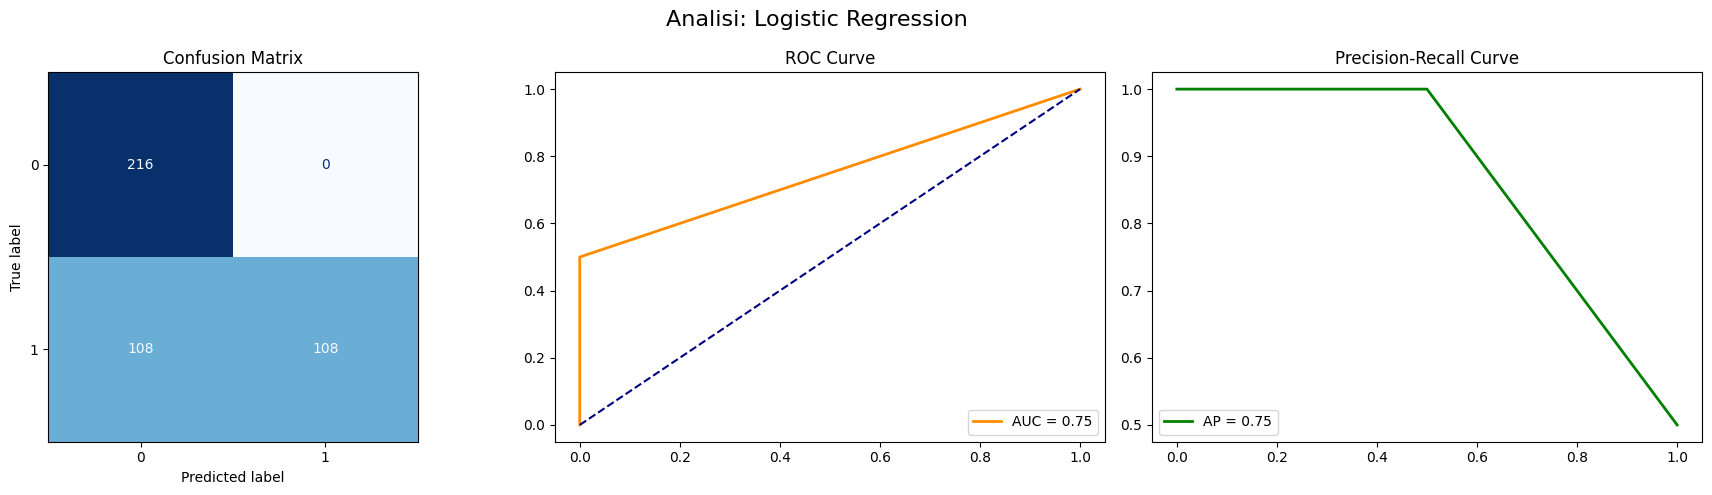

In [13]:
best_lr = grid_lr.best_estimator_
print(f"Miglior Configurazione Logistic: {grid_lr.best_params_}")

plot_full_analysis(best_lr, X_test, y_test, "Logistic Regression")

La CM evidenzia come il modello sia perfettamente in grado di classificare a 0 un punto, mentre invece la corretta classificazione a 1 è casuale (50%).

La ROC Curve è talmente spigolosa da essere un triangolo!

C'è un punto di gomito per il punto (0,0.5), confermando quanto visto grazie alla CM, il modello può trovare fino al 50% degli 1 senza mai missclassificare gli 0, da lì in poi le performance sono random (linea diagonale).

**RIDGE CLASSIFIER PER MONK-1**

In [14]:
print("RIDGE CLASSIFIER PER MONK-1")

# Parametri
param_grid_ridge = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 5.0, 10.0, 100.0, 500.0]
}

# Modello base
model_ridge = RidgeClassifier()

# Grid Search
grid_ridge = GridSearchCV(model_ridge, param_grid_ridge, cv=5, scoring='accuracy', n_jobs=None)
grid_ridge.fit(X_train, y_train)

# Risultati Validation
analyze_grid_results(grid_ridge)

RIDGE CLASSIFIER PER MONK-1
Analisi dei risultati su Validation Set (CV):
   rank_test_score  mean_test_score  std_test_score  param_alpha
0                1         0.530667        0.137895        0.001
1                1         0.530667        0.137895        0.010
2                1         0.530667        0.137895        0.100
3                1         0.530667        0.137895        1.000
4                5         0.522667        0.132370        5.000
7                5         0.522667        0.139434      500.000
6                7         0.515000        0.129074      100.000
5                8         0.514667        0.138204       10.000
------------------------------------------------------------


Da questa GridSearch notiamo la presenza di un Plateau, visto che per il range che di alpha [0.001, 1.0] non abbiamo la minima variazione del MSE, mentre invece aumentando la regolarizzazione i valori di MSE peggiorano

La Deviazione Standard di 0.137895  in rapporto ad un MSE intorno a 0.47 rende questo valore pessimo. a seconda del cv posso avere Mse = 0.30 o 0.60

Miglior Configurazione Ridge: {'alpha': 0.001}

>>> RISULTATI TEST SET: Ridge Classifier <<<
Accuracy: 73.61%
MSE:      0.2639


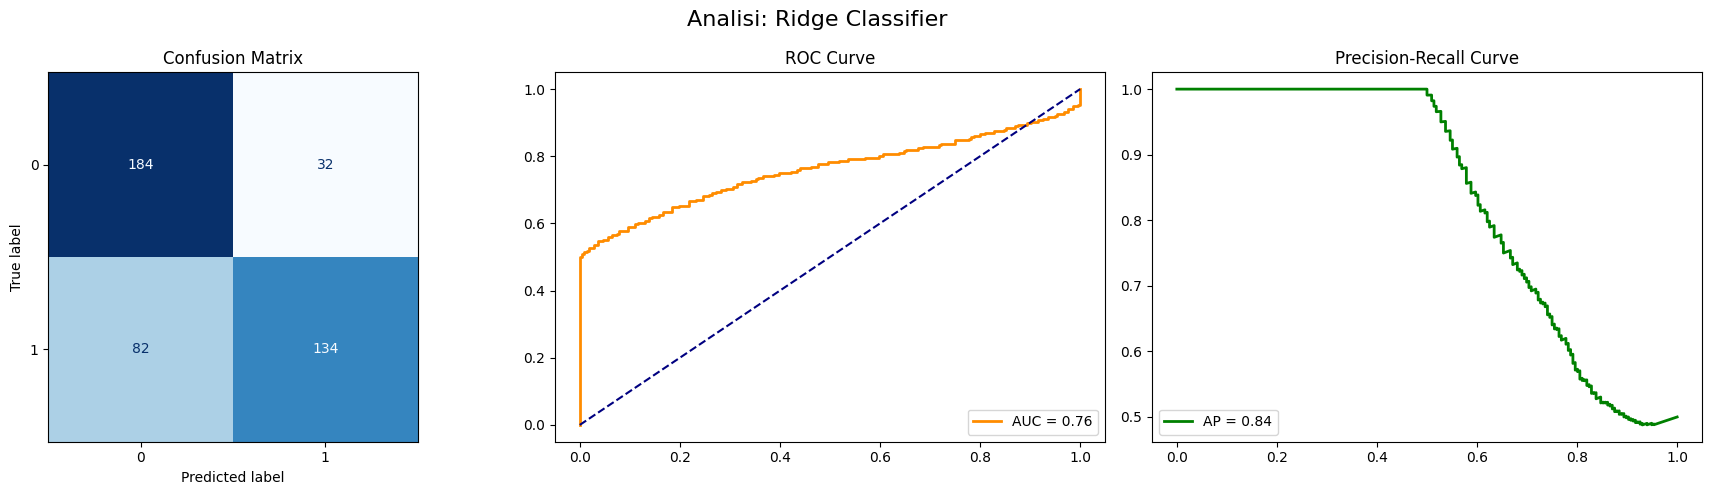

In [15]:
best_ridge = grid_ridge.best_estimator_
print(f"Miglior Configurazione Ridge: {grid_ridge.best_params_}")

plot_full_analysis(best_ridge, X_test, y_test, "Ridge Classifier")

Prima cosa che notiamo è il valore di MSE del test minore di quello del training-> possibile underfitting.

Per quanto riguarda ROC e precision recall ci sono delle somiglianze con Logistic, come il punto di gomito a (0, 0.5) però il non avere più diagonali dritte ci porta a pensare che comunque vi sia stato un tentativo di apprendimento, a differenza della casualità di Logistic. 

CM di mostra infatti come siano stati predetti correttamente 134 valori a 1, contro i 108 precedenti, ma al costo di missclassificare 32 valori a 0.

**K-NN PER MONK-1**

In [16]:
print("K-NN PER MONK-1")

# Parametri K-NN da testare
param_grid_knn = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2] # p=1 Manhattan, p=2 Euclidea
}

model_knn = KNeighborsClassifier()

# Grid Search (usiamo neg_mean_squared_error per coerenza con SVM e Ridge)
grid_knn = GridSearchCV(model_knn, param_grid_knn, cv=5, scoring='accuracy', n_jobs=None)
grid_knn.fit(X_train, y_train)

# Stampa tabella risultati Validation
analyze_grid_results(grid_knn)

K-NN PER MONK-1
Analisi dei risultati su Validation Set (CV):
    rank_test_score  mean_test_score  std_test_score  param_n_neighbors  param_p param_weights
24                1         0.612000        0.107033                 15        1       uniform
26                1         0.612000        0.107033                 15        2       uniform
25                3         0.604000        0.096664                 15        1      distance
27                3         0.604000        0.096664                 15        2      distance
20                5         0.595667        0.082916                 11        1       uniform
22                5         0.595667        0.082916                 11        2       uniform
21                7         0.595333        0.117220                 11        1      distance
15                8         0.580667        0.073768                  7        2      distance
14                8         0.580667        0.073768                  7        2   

Performance poco superiori al caso -> nulla di che

Vincono modelli con K alto -> comportamento dal majority voting globale : K=15  su 124 campioni, ogni predizione deve confrontare il 12% del dataset.

p : [1, 2] -> parametro che indica diff tra manhattan e euclid non influisce sul risultato, entrambe le metriche inducono lo stesso ordinamento dei vicini

Miglior Configurazione K-NN: {'n_neighbors': 15, 'p': 1, 'weights': 'uniform'}

>>> RISULTATI TEST SET: K-NN (Monk-1) <<<
Accuracy: 77.31%
MSE:      0.2269


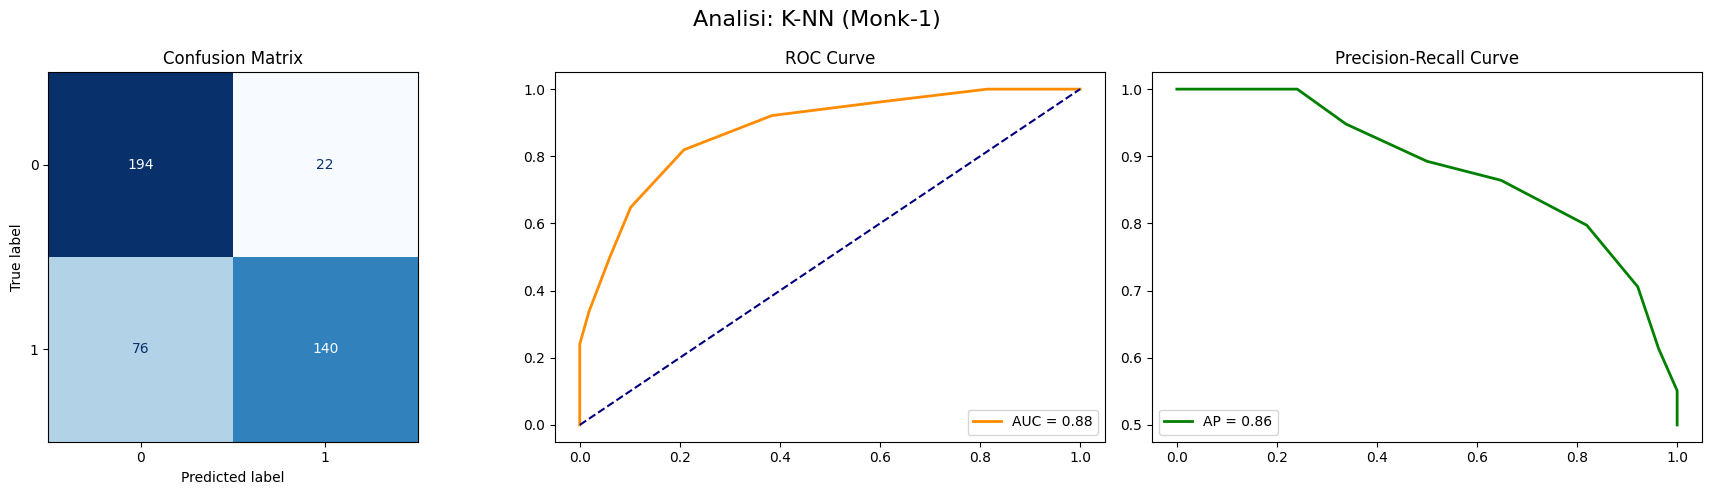

In [17]:
print(f"Miglior Configurazione K-NN: {grid_knn.best_params_}")

# Valutazione sul Test Set utilizzando la funzione di project_utils
plot_full_analysis(grid_knn.best_estimator_, X_test, y_test, "K-NN (Monk-1)")

L'accuracy sul test set è ~77.3%, nettamente migliore della validation, test ha più sample.

**SVM PER MONK-1**

In [18]:
print("SVM PER MONK-1")

# Parametri (Lista di dizionari per Kernel diversi)
param_grid_svm = [
    # Kernel Lineare
    {'kernel': ['linear'], 'C': [0.01, 0.1, 1, 10, 100]},
    
    {'kernel': ['poly'], 'degree': [2, 3], 'C': [0.1, 1, 10], 'coef0': [0, 1]},
    
    # Kernel RBF
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.1, 1, 5, 10, 100]},
    
    # Kernel Sigmoideo
    {'kernel': ['sigmoid'], 'C': [0.1, 1, 10], 'coef0': [0, 1, -1]}
]

# Modello Base
model_svm = SVC() # Nota: per ROC servirebbe probability=True, ma SVC usa decision_function che va bene uguale

# Grid Search
grid_svm = GridSearchCV(model_svm, param_grid_svm, cv=5, scoring='accuracy', n_jobs=None)
grid_svm.fit(X_train, y_train)

# Risultati Validation
analyze_grid_results(grid_svm)

SVM PER MONK-1
Analisi dei risultati su Validation Set (CV):
    rank_test_score  mean_test_score  std_test_score  param_C param_kernel  param_coef0  param_degree param_gamma
15                1         0.796333        0.180371     10.0         poly          1.0           2.0         NaN
12                2         0.788333        0.182678      1.0         poly          1.0           3.0         NaN
13                2         0.788333        0.182678     10.0         poly          0.0           2.0         NaN
16                2         0.788333        0.182678     10.0         poly          1.0           3.0         NaN
36                5         0.748333        0.137832    100.0          rbf          NaN           NaN         0.1
14                6         0.691333        0.152776     10.0         poly          0.0           3.0         NaN
30                7         0.676333        0.077806     10.0          rbf          NaN           NaN         0.1
10                8        

La GridSearch ci dice  che il vincitore è il kernel polinomiale, di grado 2 e con un valore medio alto della regolarizzazione. Inoltre notiamo come nelle prime posizioni il kernel 'poly' è dominante, altra conferma della sua vittoria.

Il kernel Polinomiale non guarda solo le singole features ma crea delle iterazioni tra di esse.

Miglior Configurazione SVM: {'C': 10, 'coef0': 1, 'degree': 2, 'kernel': 'poly'}

>>> RISULTATI TEST SET: SVM <<<
Accuracy: 100.00%
MSE:      0.0000


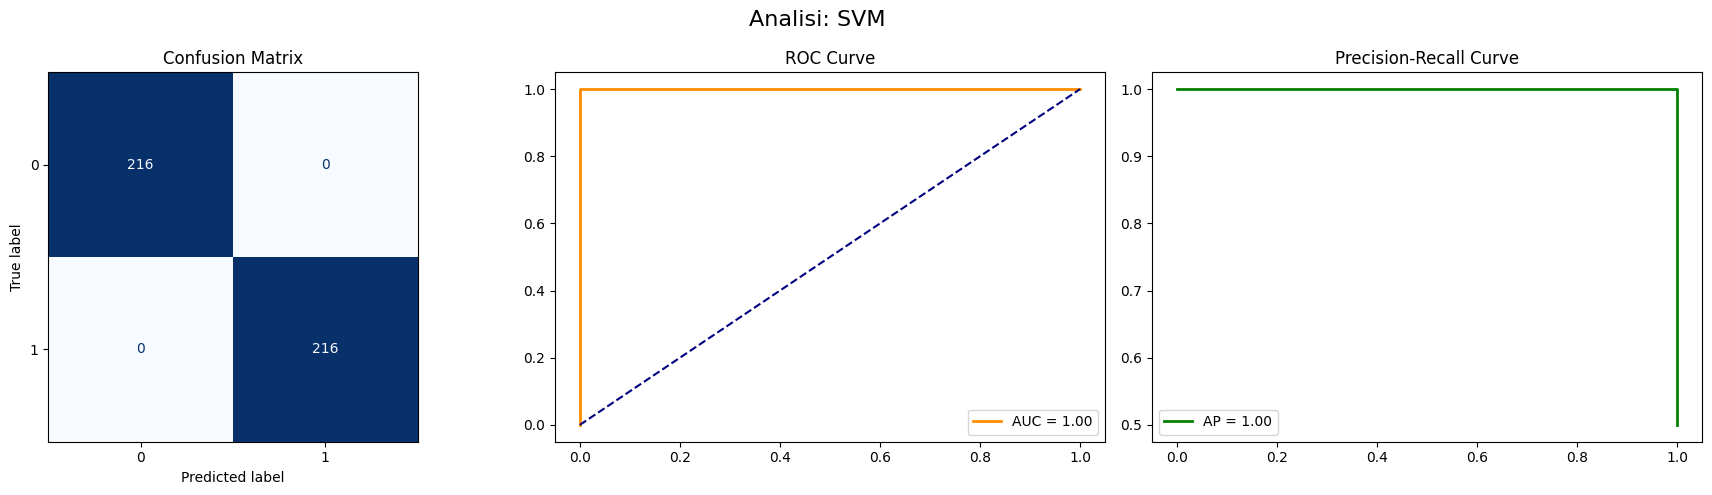

In [19]:
best_svm = grid_svm.best_estimator_
print(f"Miglior Configurazione SVM: {grid_svm.best_params_}")

plot_full_analysis(best_svm, X_test, y_test, "SVM")

L'accuracy sul test set è perfette!

 Reminder personale : coef0=1 permette al modello di pesare anche i temini di grado inferiore a quello scelto (2).

Note finali:

Il primo dataset ha dimostrato di non essere linearmente separabile. Mentre i classificatori lineari hanno raggiunto un plateau di performance (circa 75%) sfruttando solo le correlazioni semplici, l'introduzione di non-linearità tramite SVM con kernel polinomiale è stata determinante per catturare le interazioni tra feature necessarie a risolvere il problema logico sottostante, raggiungendo il 100% di accuratezza

---
**MONK-2**:

**PREPROCESSING MONK-2** : Identico a MONK-1

In [20]:
# Configurazione Dataset
DATASET_NAME = 'monks-2'
TRAIN_PATH = './datasets/monks-2.train'
TEST_PATH = './datasets/monks-2.test'

# Caricamento
loader = MonkLoader(DATASET_NAME)
X_train, y_train, X_test, y_test = loader.get_data(TRAIN_PATH, TEST_PATH)

# Verifica shape
print(f"Dati caricati per {DATASET_NAME}")
print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")

--- Dataset Loaded: monks-2 ---
X_train shape: (169, 17) | Type: float32
y_train shape: (169,)        | Type: int64
X_test shape:  (432, 17)
Features originali: 6 -> OneHot Features: 17
----------------------------------------
Dati caricati per monks-2
Train shape: (169, 17)
Test shape:  (432, 17)


**LOGISTIC REGRESSION PER MONK-2**:

In [21]:
print("LOGISTIC REGRESSION PER MONK-2")

# Parametri da testare
param_grid_lr = {
    'solver': ['saga'],
    'penalty': ['l1', 'l2', 'none'],
    'C': [0.01, 0.1, 1, 10, 100],
    'max_iter': [5000]
}

model_lr = LogisticRegression(random_state=42)

# Esegui Grid Search
grid_lr = GridSearchCV(model_lr, param_grid_lr, cv=5, scoring='accuracy', n_jobs=None)
grid_lr.fit(X_train, y_train)

# Stampa tabella risultati Validation
analyze_grid_results(grid_lr)

LOGISTIC REGRESSION PER MONK-2
Analisi dei risultati su Validation Set (CV):
    rank_test_score  mean_test_score  std_test_score  param_C  param_max_iter param_penalty param_solver
1                 1         0.621390        0.007487     0.01            5000            l2         saga
3                 1         0.621390        0.007487     0.10            5000            l1         saga
0                 3         0.566845        0.101604     0.01            5000            l1         saga
4                 4         0.513547        0.118225     0.10            5000            l2         saga
9                 5         0.497148        0.126995    10.00            5000            l1         saga
7                 6         0.496970        0.119263     1.00            5000            l2         saga
10                7         0.485383        0.128896    10.00            5000            l2         saga
6                 8         0.484670        0.108979     1.00            5000      

La GridSearch ci mostra come i vincitori siano modelli con alta regolarizzazione (c basso) ma un risultato veramente pessimo. facciamo solo poco più del lancio della moneta, ancora peggio nel caso peggiore dove allentiamo la regolarizzazione. Probabilmente è un dataset fortemente non lineare

Miglior Configurazione Logistic: {'C': 0.01, 'max_iter': 5000, 'penalty': 'l2', 'solver': 'saga'}

>>> RISULTATI TEST SET: Logistic Regression <<<
Accuracy: 67.13%
MSE:      0.3287


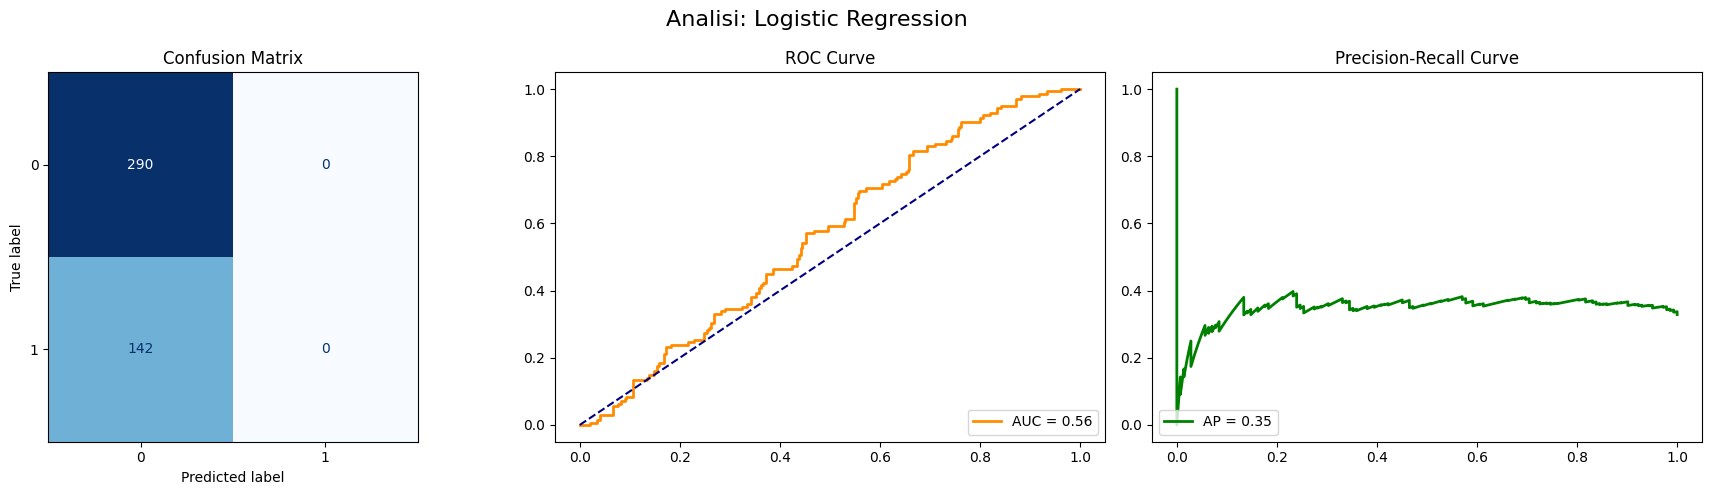

In [22]:
best_lr = grid_lr.best_estimator_
print(f"Miglior Configurazione Logistic: {grid_lr.best_params_}")

plot_full_analysis(best_lr, X_test, y_test, "Logistic Regression")

I grafici ci dicono chiaramente che il comportamento del modello per il dataset MONK-2 è quello di dire "per evitare di sbagliare classifico tutto a 0", si vede chiaramente dalla CM. Evidentemente il problema è ancora una volta non lineare, ed il modello Log Reg ha azzerato tutte le feature (l1 reg) visto che non riusciva a tracciare un iperpiano separatore

**RIDGE CLASSIFIER PER MONK-2**:

In [23]:
print("RIDGE CLASSIFIER PER MONK-2")

# Parametri
param_grid_ridge = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 5.0, 10.0, 100.0, 500.0]
}

model_ridge = RidgeClassifier()

# Grid Search
grid_ridge = GridSearchCV(model_ridge, param_grid_ridge, cv=5, scoring='accuracy', n_jobs=None)
grid_ridge.fit(X_train, y_train)

# Risultati Validation
analyze_grid_results(grid_ridge)

RIDGE CLASSIFIER PER MONK-2
Analisi dei risultati su Validation Set (CV):
   rank_test_score  mean_test_score  std_test_score  param_alpha
7                1         0.621390        0.007487      500.000
6                2         0.615508        0.015443      100.000
4                3         0.502674        0.123632        5.000
0                4         0.491266        0.121854        0.001
1                4         0.491266        0.121854        0.010
2                4         0.491266        0.121854        0.100
3                7         0.485205        0.121268        1.000
5                8         0.484670        0.121015       10.000
------------------------------------------------------------


Miglior Configurazione Ridge: {'alpha': 500.0}

>>> RISULTATI TEST SET: Ridge Classifier <<<
Accuracy: 67.13%
MSE:      0.3287


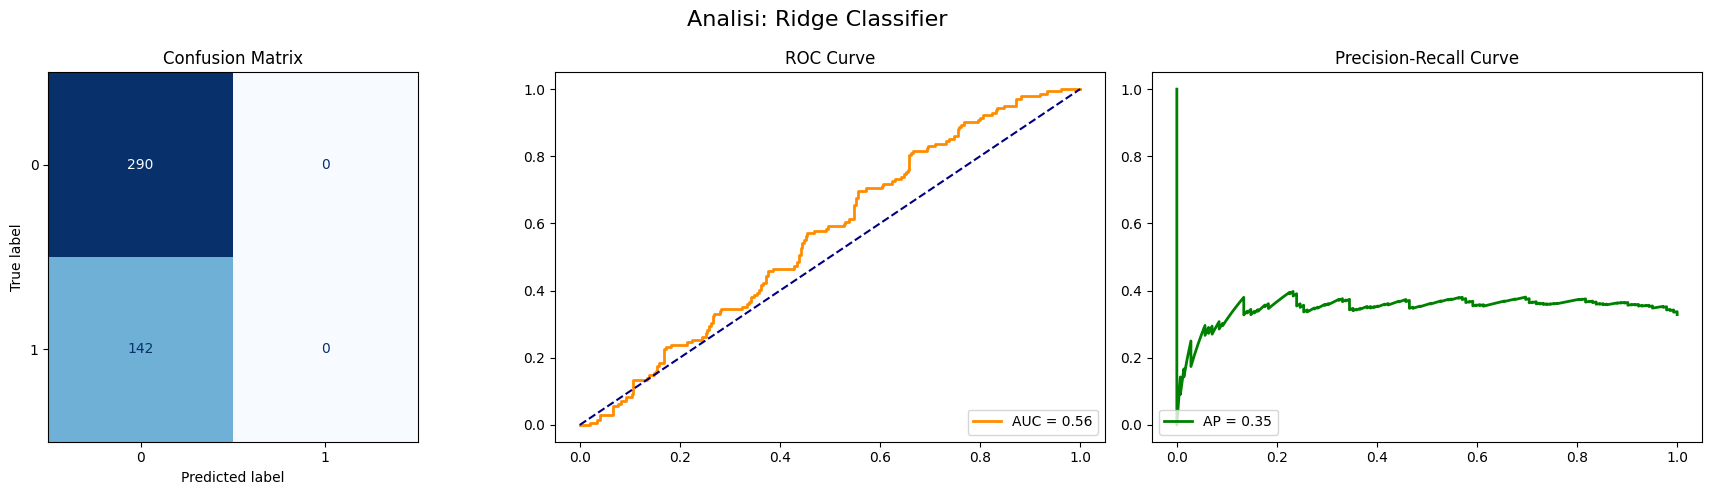

In [24]:
best_ridge = grid_ridge.best_estimator_
print(f"Miglior Configurazione Ridge: {grid_ridge.best_params_}")

plot_full_analysis(best_ridge, X_test, y_test, "Ridge Classifier")

Combinando grid search e grafici vediamo un comportamento molto simile a logistic. i pesi sono stati tutti schiacciati a circa 0, circa perché uso L2 e non L1, portando il classificatore a comportarsi come un dummy classifier che predice solo la classe di maggioranza

**K-NN PER MONK-2**:

In [25]:
print("K-NN PER MONK-2")

# Parametri K-NN da testare
param_grid_knn = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2] # p=1 Manhattan, p=2 Euclidea
}

model_knn = KNeighborsClassifier()

# Grid Search (usiamo neg_mean_squared_error per coerenza con SVM e Ridge)
grid_knn = GridSearchCV(model_knn, param_grid_knn, cv=5, scoring='accuracy', n_jobs=None)
grid_knn.fit(X_train, y_train)

# Stampa tabella risultati Validation
analyze_grid_results(grid_knn)

K-NN PER MONK-2
Analisi dei risultati su Validation Set (CV):
    rank_test_score  mean_test_score  std_test_score  param_n_neighbors  param_p param_weights
27                1         0.568093        0.050662                 15        2      distance
24                2         0.562032        0.057556                 15        1       uniform
26                2         0.562032        0.057556                 15        2       uniform
22                4         0.544207        0.052564                 11        2       uniform
20                4         0.544207        0.052564                 11        1       uniform
25                6         0.544029        0.051046                 15        1      distance
9                 7         0.533155        0.064628                  5        1      distance
17                8         0.532799        0.080458                  9        1      distance
3                 9         0.532620        0.081336                  1        2   

Similmente a MONK-1 i vincitori hanno K alto -> Majority-class voting

Accuracy migliore è veramente di poco sopra il lancio della moneta (0.56), addirittura peggio del migliore di Ridge/Logistic dove classificavamo tutto a 0

p irrilevante come per MONK-1

Miglior Configurazione K-NN: {'n_neighbors': 15, 'p': 2, 'weights': 'distance'}

>>> RISULTATI TEST SET: K-NN (Monk-2) <<<
Accuracy: 75.93%
MSE:      0.2407


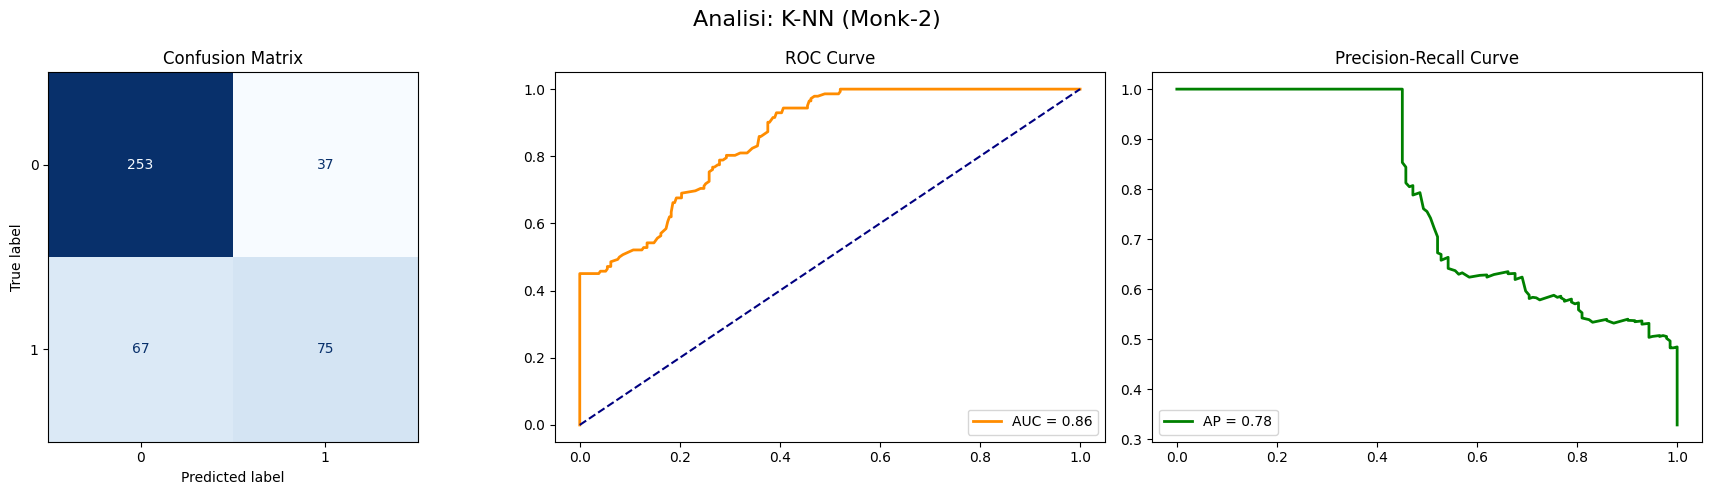

In [26]:
print(f"Miglior Configurazione K-NN: {grid_knn.best_params_}")

# Valutazione sul Test Set utilizzando la funzione di project_utils
plot_full_analysis(grid_knn.best_estimator_, X_test, y_test, "K-NN (Monk-2)")

Riesce a classificare correttamente alcuni valori positivi (75 su 142), dimostrando la necessità della non linearità.

AUC elevato (0.86) lo score basato sulla proporzione dei vicini ha un buon potere di ranking.

**SVM PER MONK-2**:

In [27]:
print("SVM PER MONK-2")

# Parametri (Lista di dizionari per Kernel diversi)
param_grid_svm = [
    # Kernel Lineare
    {'kernel': ['linear'], 'C': [0.01, 0.1, 1, 10, 100]},
    
    # Kernel Polinomiale 
    {'kernel': ['poly'], 'degree': [2, 3, 4], 'C': [0.1, 1, 10], 'coef0': [0, 1]},
    
    # Kernel RBF
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.1, 1, 5, 10, 100]},
    
    # Kernel Sigmoideo
    {'kernel': ['sigmoid'], 'C': [0.1, 1, 10], 'coef0': [0, 1, -1]}
]

model_svm = SVC() # Nota: per ROC servirebbe probability=True, ma SVC usa decision_function che va bene uguale

# Grid Search
grid_svm = GridSearchCV(model_svm, param_grid_svm, cv=5, scoring='accuracy', n_jobs=None)
grid_svm.fit(X_train, y_train)

# Risultati Validation
analyze_grid_results(grid_svm)

SVM PER MONK-2
Analisi dei risultati su Validation Set (CV):
    rank_test_score  mean_test_score  std_test_score  param_C param_kernel  param_coef0  param_degree param_gamma
21                1         0.692513        0.042613    10.00         poly          1.0           3.0         NaN
16                2         0.663280        0.055179     1.00         poly          1.0           4.0         NaN
22                2         0.663280        0.055179    10.00         poly          1.0           4.0         NaN
17                4         0.657219        0.058590    10.00         poly          0.0           2.0         NaN
42                5         0.650980        0.067526   100.00          rbf          NaN           NaN         0.1
20                6         0.645276        0.039155    10.00         poly          1.0           2.0         NaN
18                7         0.633868        0.065916    10.00         poly          0.0           3.0         NaN
0                 8        

Notiamo intento che il vincitore sia un polinomio di grado 3, a segnalare una complessità del dataset superiore a monk-1. Con un termine di penalità intermedio e coef0=1

Miglior Configurazione SVM: {'C': 10, 'coef0': 1, 'degree': 3, 'kernel': 'poly'}

>>> RISULTATI TEST SET: SVM <<<
Accuracy: 85.65%
MSE:      0.1435


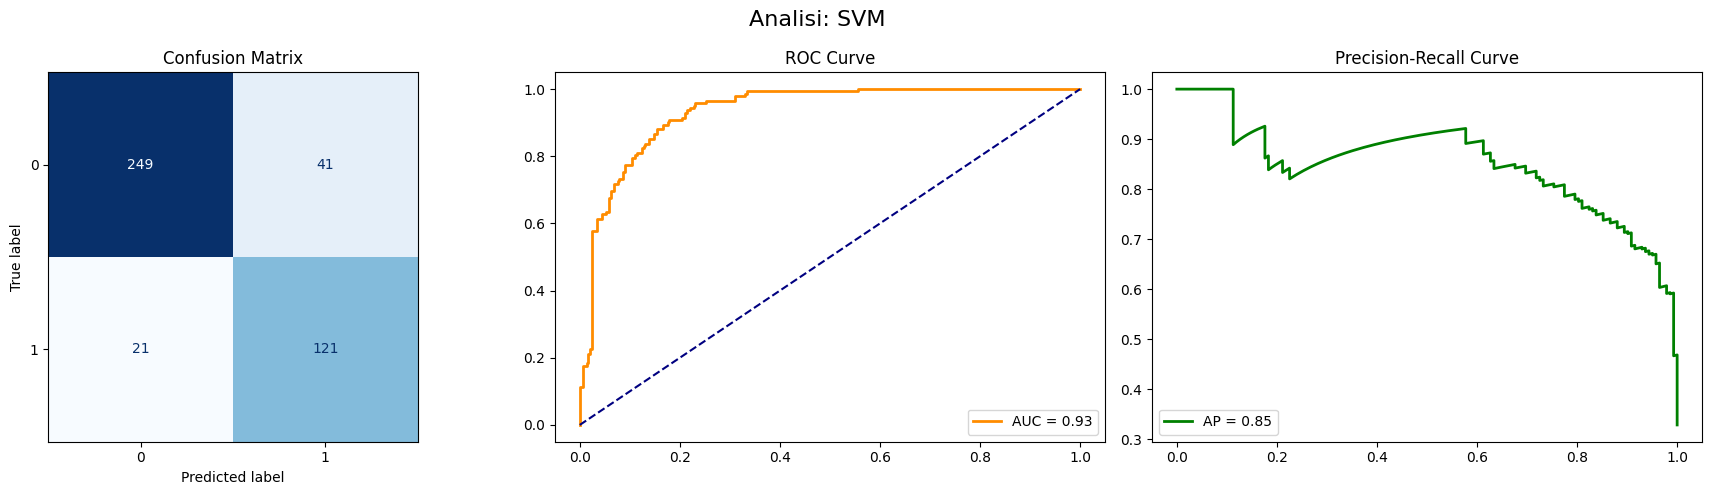

In [6]:
best_svm = grid_svm.best_estimator_
print(f"Miglior Configurazione SVM: {grid_svm.best_params_}")

plot_full_analysis(best_svm, X_test, y_test, "SVM")

Dalla CM possiamo constatare che sia stato necessario un polinomiale di grado 3 per ottenere dell'apprendimento, altro punto per la difficoltà del dataset

AUC è passato da 0.5 dei modelli lineari a 0.93.

Possiamo sempre di più affermare che Monk-2 sia un problema Non-Lineare Complesso, inoltre il fatto che SVM polinomiale di grado 3 abbia trovato "solo" un accuracy del 85%, contro il 100% di Monk-1 (con grado 2), ci porta a pensare che la sua regola logica sia ancora più complicata.

---
**MONK-3**

**PRE-PROCESSING**: Esattamente come i precedenti

In [28]:
# Configurazione Dataset
DATASET_NAME = 'monks-3'
TRAIN_PATH = './datasets/monks-3.train'
TEST_PATH = './datasets/monks-3.test'

# Caricamento
loader = MonkLoader(DATASET_NAME)
X_train, y_train, X_test, y_test = loader.get_data(TRAIN_PATH, TEST_PATH)

# Verifica shape
print(f"Dati caricati per {DATASET_NAME}")
print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")

--- Dataset Loaded: monks-3 ---
X_train shape: (122, 17) | Type: float32
y_train shape: (122,)        | Type: int64
X_test shape:  (432, 17)
Features originali: 6 -> OneHot Features: 17
----------------------------------------
Dati caricati per monks-3
Train shape: (122, 17)
Test shape:  (432, 17)


**LOGISTIC REGRESSION PER MONK-3**

In [29]:
print("LOGISTIC REGRESSION PER MONK-3")

# Parametri da testare
param_grid_lr = {
    'solver': ['saga'],
    'penalty': ['l1', 'l2', 'none'],
    'C': [0.01, 0.1, 1, 10, 100],
    'max_iter': [5000]
}

model_lr = LogisticRegression(random_state=42)

# Grid Search
grid_lr = GridSearchCV(model_lr, param_grid_lr, cv=5, scoring='accuracy', n_jobs=None)
grid_lr.fit(X_train, y_train)

# Stampa tabella risultati Validation
analyze_grid_results(grid_lr)

LOGISTIC REGRESSION PER MONK-3
Analisi dei risultati su Validation Set (CV):
    rank_test_score  mean_test_score  std_test_score  param_C  param_max_iter param_penalty param_solver
6                 1         0.934000        0.042251     1.00            5000            l1         saga
7                 2         0.925667        0.040710     1.00            5000            l2         saga
4                 3         0.917667        0.044766     0.10            5000            l2         saga
10                4         0.900667        0.067877    10.00            5000            l2         saga
9                 5         0.884000        0.096705    10.00            5000            l1         saga
1                 6         0.869000        0.014629     0.01            5000            l2         saga
13                7         0.867667        0.092907   100.00            5000            l2         saga
12                8         0.834333        0.115247   100.00            5000      

Miglior Configurazione Logistic: {'C': 1, 'max_iter': 5000, 'penalty': 'l1', 'solver': 'saga'}

>>> RISULTATI TEST SET: Logistic Regression <<<
Accuracy: 97.22%
MSE:      0.0278


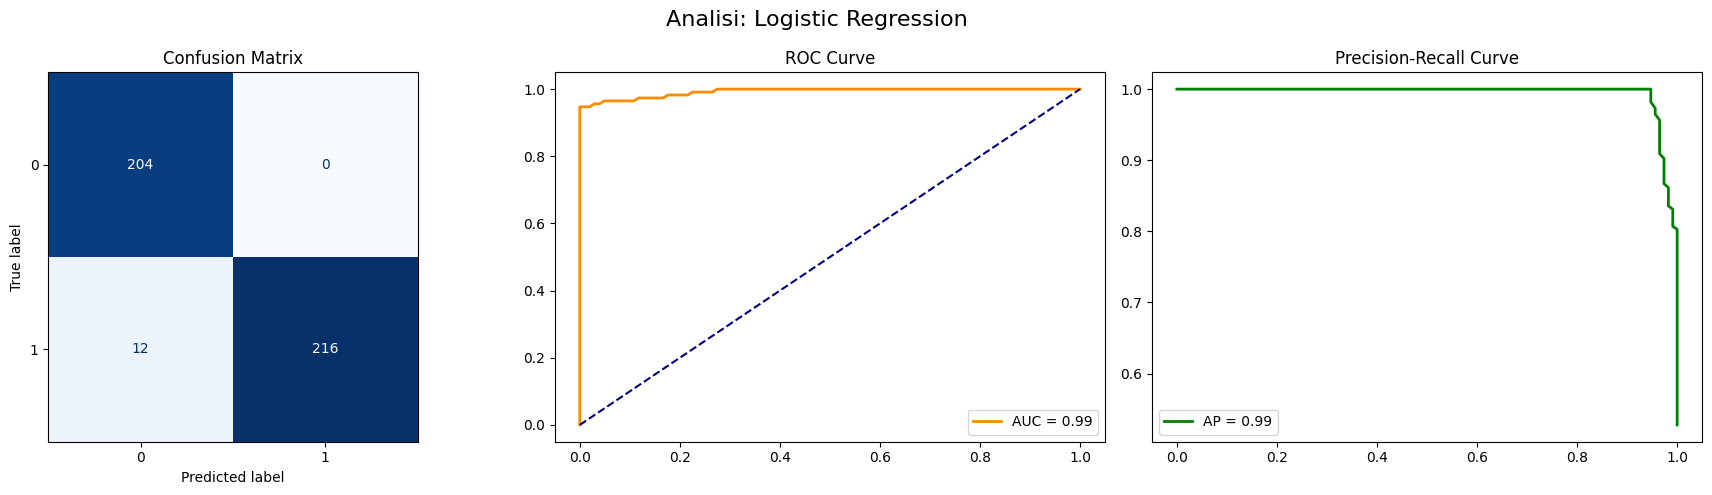

In [30]:
best_lr = grid_lr.best_estimator_
print(f"Miglior Configurazione Logistic: {grid_lr.best_params_}")

plot_full_analysis(best_lr, X_test, y_test, "Logistic Regression")

Notiamo che per Monk-3 i risultati sono sostanzialmente diversi dai precedenti. Il modello lineare con un valore di regolarizzazione equilibrato (c=1) e la vittoria della reg L1 ci fa ipotizzare che ci siano features meno rilevanti.

Informazioni molto utili ce le danno anche i grafici, CM dice che il modello ha classificato correttamente tutti gli elementi a 0, ma ha fatto qualche errore per la classe 1

**RIDGE CLASSIFIER PER MONK-3**:

In [31]:
print("RIDGE CLASSIFIER PER MONK-3")

# Parametri
param_grid_ridge = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 5.0, 10.0, 100.0, 500.0]
}

model_ridge = RidgeClassifier()

# Grid Search
grid_ridge = GridSearchCV(model_ridge, param_grid_ridge, cv=5, scoring='accuracy', n_jobs=None)
grid_ridge.fit(X_train, y_train)

# Risultati Validation
analyze_grid_results(grid_ridge)

RIDGE CLASSIFIER PER MONK-3
Analisi dei risultati su Validation Set (CV):
   rank_test_score  mean_test_score  std_test_score  param_alpha
5                1         0.909667        0.053504       10.000
6                2         0.901667        0.040906      100.000
4                3         0.901333        0.054989        5.000
0                4         0.885000        0.069602        0.001
3                4         0.885000        0.069602        1.000
2                4         0.885000        0.069602        0.100
1                4         0.885000        0.069602        0.010
7                8         0.877000        0.025417      500.000
------------------------------------------------------------


Miglior Configurazione Ridge: {'alpha': 10.0}

>>> RISULTATI TEST SET: Ridge Classifier <<<
Accuracy: 97.22%
MSE:      0.0278


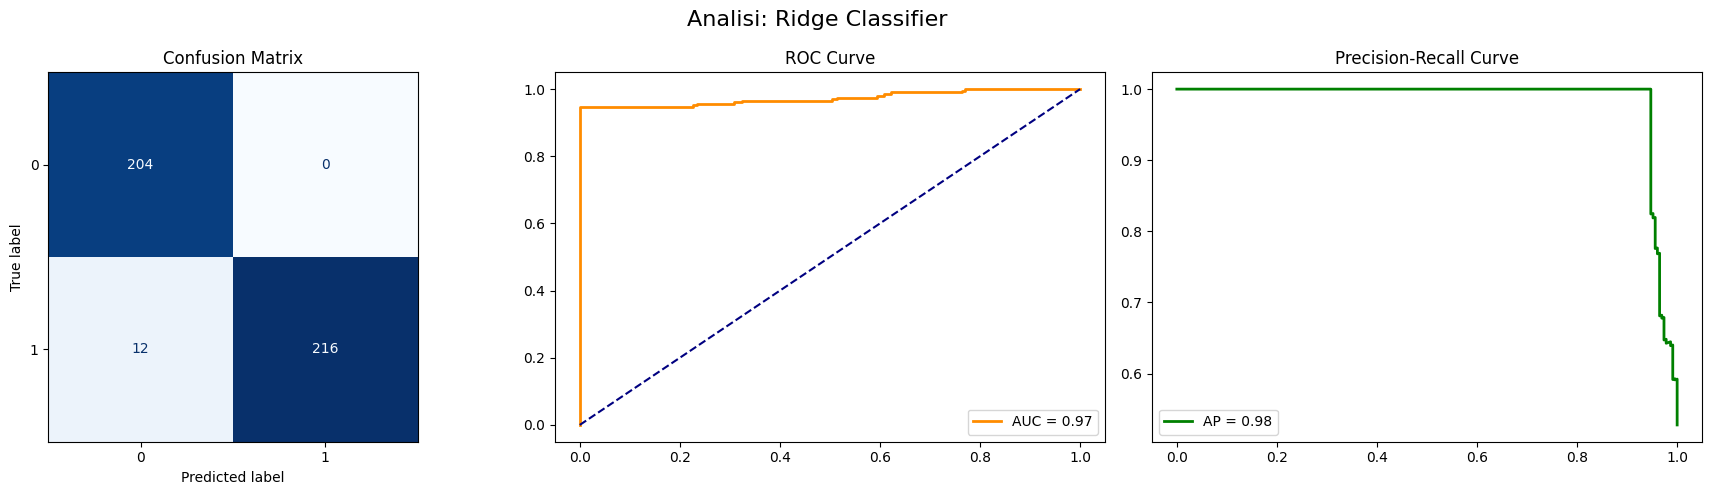

In [32]:
best_ridge = grid_ridge.best_estimator_
print(f"Miglior Configurazione Ridge: {grid_ridge.best_params_}")

plot_full_analysis(best_ridge, X_test, y_test, "Ridge Classifier")

Il risultato è identico al precedente nonostante i modelli siano diverse. con addirirttura regolarizzazioni diverse (prima ha vinto L1, mentre ridge utilizza L2). I grafici inoltre mostrano come l'accuracy non sia uguale solo a livello numerico, ma anche nella "disposizione" dell'errore (12 errate classificazioni di 1)

**K-NN PER MONK-3**

In [ ]:
print("K-NN PER MONK-3")

# Parametri K-NN da testare
param_grid_knn = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2] # p=1 Manhattan, p=2 Euclidea
}

model_knn = KNeighborsClassifier()

# Grid Search
grid_knn = GridSearchCV(model_knn, param_grid_knn, cv=5, scoring='accuracy', n_jobs=None)
grid_knn.fit(X_train, y_train)

# Stampa tabella risultati Validation
analyze_grid_results(grid_knn)

K-NN PER MONK-3
Analisi dei risultati su Validation Set (CV):
    rank_test_score  mean_test_score  std_test_score  param_n_neighbors  param_p param_weights
23                1         0.836333        0.077563                 11        2      distance
20                1         0.836333        0.077563                 11        1       uniform
22                1         0.836333        0.077563                 11        2       uniform
21                4         0.836000        0.069798                 11        1      distance
25                5         0.835667        0.046638                 15        1      distance
15                6         0.827667        0.018245                  7        2      distance
14                6         0.827667        0.018245                  7        2       uniform
12                6         0.827667        0.018245                  7        1       uniform
26                9         0.819667        0.055321                 15        2   

Miglior Configurazione K-NN: {'n_neighbors': 11, 'p': 1, 'weights': 'uniform'}

>>> RISULTATI TEST SET: K-NN (Monk-3) <<<
Accuracy: 89.12%
MSE:      0.1088


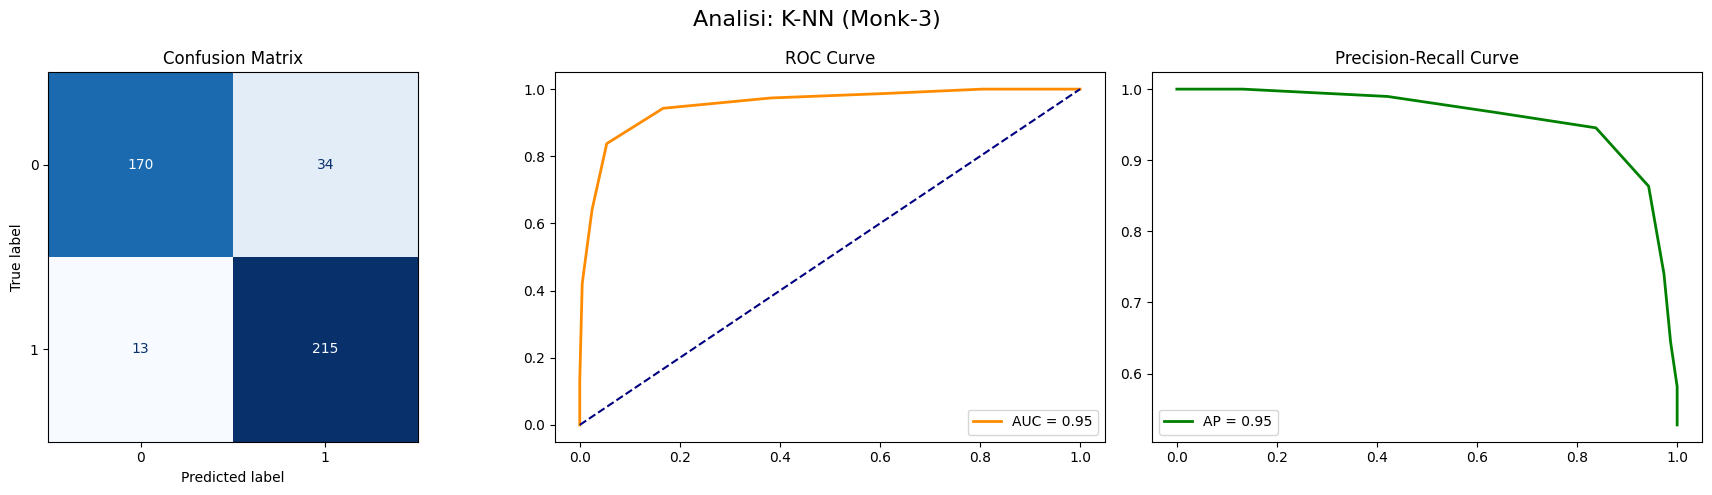

In [34]:
print(f"Miglior Configurazione K-NN: {grid_knn.best_params_}")

# Valutazione sul Test Set 
plot_full_analysis(grid_knn.best_estimator_, X_test, y_test, "K-NN (Monk-3)")

**SVM PER MONK-3**

In [35]:
print("SVM PER MONK-3")

# Parametri (Lista di dizionari per Kernel diversi)
param_grid_svm = [
    # Kernel Lineare
    {'kernel': ['linear'], 'C': [0.01, 0.1, 1, 10, 100]},
    
    # Kernel Polinomiale 
    {'kernel': ['poly'], 'degree': [2, 3], 'C': [0.1, 1, 10], 'coef0': [0, 1]},
    
    # Kernel RBF
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.1, 1, 5, 10, 100]},
    
    # Kernel Sigmoideo
    {'kernel': ['sigmoid'], 'C': [0.1, 1, 10], 'coef0': [0, 1, -1]}
]


model_svm = SVC() # Nota: per ROC servirebbe probability=True, ma SVC usa decision_function che va bene uguale

# Grid Search
grid_svm = GridSearchCV(model_svm, param_grid_svm, cv=5, scoring='accuracy', n_jobs=None)
grid_svm.fit(X_train, y_train)

# Risultati Validation
analyze_grid_results(grid_svm)

SVM PER MONK-3
Analisi dei risultati su Validation Set (CV):
    rank_test_score  mean_test_score  std_test_score  param_C param_kernel  param_coef0  param_degree param_gamma
1                 1         0.934000        0.042251      0.1       linear          NaN           NaN         NaN
2                 1         0.934000        0.042251      1.0       linear          NaN           NaN         NaN
3                 1         0.934000        0.042251     10.0       linear          NaN           NaN         NaN
4                 1         0.934000        0.042251    100.0       linear          NaN           NaN         NaN
7                 1         0.934000        0.042251      0.1         poly          1.0           2.0         NaN
8                 1         0.934000        0.042251      0.1         poly          1.0           3.0         NaN
24                1         0.934000        0.042251      1.0          rbf          NaN           NaN         0.1
46                1        

Notiamo già come abbia vinto linear, mai successo prima

Miglior Configurazione SVM: {'C': 0.1, 'kernel': 'linear'}

>>> RISULTATI TEST SET: SVM <<<
Accuracy: 97.22%
MSE:      0.0278


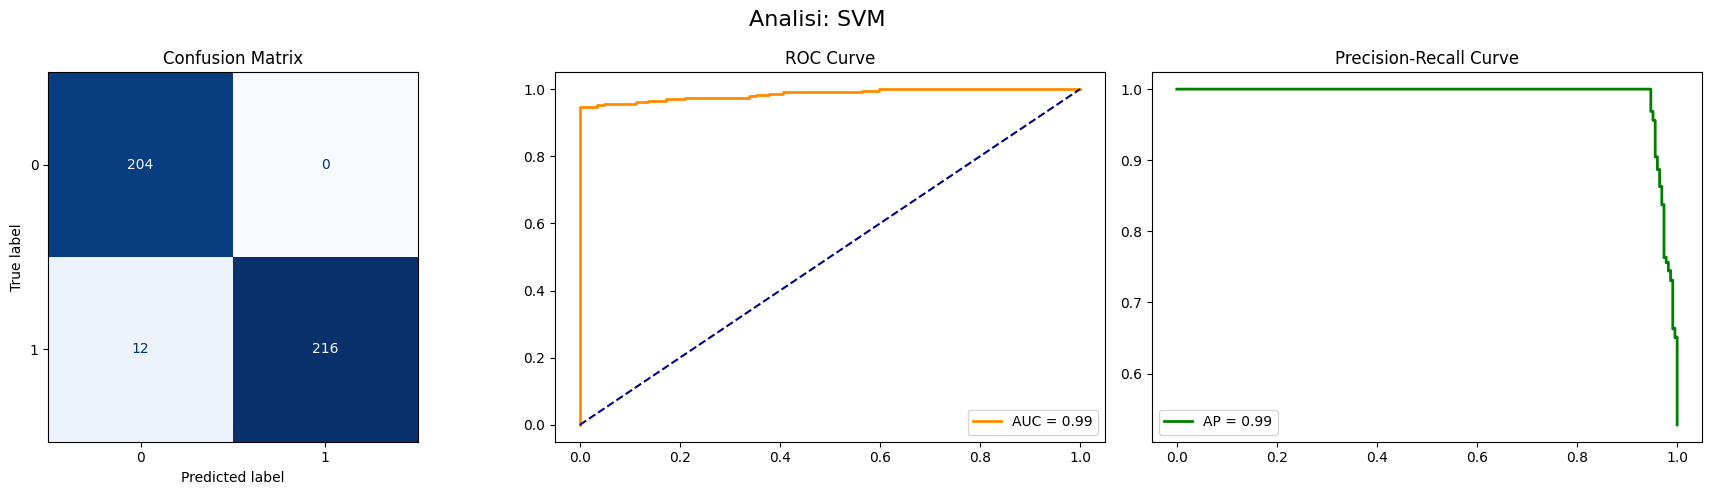

In [36]:
best_svm = grid_svm.best_estimator_
print(f"Miglior Configurazione SVM: {grid_svm.best_params_}")

plot_full_analysis(best_svm, X_test, y_test, "SVM")

Abbiamo un terzo modello che restituisce gli stessi risultati. Sempre più probabile la presenza di rumore che ci impedisce di arrivare al 100%.

---
**RETI NEURALI**:

**MONK-1**

MonkDataset:

Wrapper per garantire che PyTorch riceva i tensori nella forma esatta

Questo minimizza le perturbazioni numeriche e prepara i dati per la BCE, forzando il target ad appartenere al corretto spazio

In [37]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

class MonkDataset(Dataset):
    """
    Wrapper per proiettare i dati estratti dal MonkLoader 
    nel dominio tensoriale di PyTorch.
    """
    def __init__(self, X_numpy, y_numpy):
        # 1. Proiezione nello spazio delle feature (N, 17)
        # Assicuriamo il tipo float32 per un calcolo stabile del gradiente
        self.X = torch.tensor(X_numpy, dtype=torch.float32)
        
        # 2. Proiezione nello spazio dei target (N, 1)
        # .view(-1, 1) è fondamentale: trasforma il vettore riga (N,) 
        # in un vettore colonna (N, 1). Il casting a float32 prepara 
        # il tensore per la BCEWithLogitsLoss.
        self.y = torch.tensor(y_numpy, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        # Misura di Lebesgue discreta del nostro spazio campionario
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

Prima ancora di iniziare con lo studio sulla NN, rendiamo l'esperimento riproduciblie:

Fissiamo il seed al valore standard di 42.

Questo permetterà di riprodurre gli stessi valori per le matrici $\mathbf{W}_i$ dei pesi ad ogni esecuzione.

Se non li avessimo fissati : I pesi, estratti da una distribuzione uniforme $\mathcal{U}[-a, a]$, partirebbero da un punto casuale, portando a calcolare gradienti iniziali diversi,

In [38]:
# Fissiamo il seed per garantire la riproducibilità scientifica
import random
import numpy as np
import torch

def seed_everything(seed: int = 42, verbose: bool = True):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    if verbose:
        print(f"Seme fissato a: {seed}. L'esperimento è ora riproducibile.")
# Invochiamo la funzione prima di istanziare qualsiasi modello o dataset
seed_everything(seed=42)

Seme fissato a: 42. L'esperimento è ora riproducibile.


In [39]:
# Estrazione Dati e Proiezione nel Dominio Tensoriale
import torch
from dataloader import MonkLoader

# 1. Istanziamo il tuo loader universale per MONK-1
loader = MonkLoader(dataset_name='monks-1')

X_train_np, y_train_np, X_test_np, y_test_np = loader.get_data(
    './datasets/monks-1.train', 
    './datasets/monks-1.test'
)

# 2. Proiezione nello spazio tensoriale di PyTorch (Training Set)
# Il tuo encoder restituisce già float32, quindi la conversione è diretta e senza perdita
X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)

# Qui applichiamo la correzione topologica vitale per la Binary Cross Entropy:
# .view(-1, 1) trasforma la forma da (124,) a (124, 1)
# dtype=torch.float32 allinea il target all'output della rete
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32).view(-1, 1)

# 3. Prepariamo in anticipo anche il Test Set per quando valuteremo la generalizzazione
X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.float32).view(-1, 1)

print("\n--- Verifica Topologia Tensori ---")
print(f"X_train_tensor shape: {X_train_tensor.shape} | type: {X_train_tensor.dtype}")
print(f"y_train_tensor shape: {y_train_tensor.shape} | type: {y_train_tensor.dtype}")
print("I dati sono ora pronti per fluire nel Grafo Computazionale!")

--- Dataset Loaded: monks-1 ---
X_train shape: (124, 17) | Type: float32
y_train shape: (124,)        | Type: int64
X_test shape:  (432, 17)
Features originali: 6 -> OneHot Features: 17
----------------------------------------

--- Verifica Topologia Tensori ---
X_train_tensor shape: torch.Size([124, 17]) | type: torch.float32
y_train_tensor shape: torch.Size([124, 1]) | type: torch.float32
I dati sono ora pronti per fluire nel Grafo Computazionale!


In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
 
def run_experiment(X_train, y_train, X_test, y_test, 
                   activation='tanh', optimizer_name='adam', 
                   epochs=500, learning_rate=0.01, momentum=0.0):
    """
    Esegue un esperimento di addestramento completo, plottando le curve 
    di Rischio Empirico (Loss) e Accuratezza, sia per il Train che per il Test set.
    """
    # 1. Fissiamo l'entropia per garantire la comparabilità esatta tra i run
    seed_everything(42)
 
    # 2. Definizione Dinamica dell'Architettura (innestata per isolamento)
    class MonkBinaryClassifier(nn.Module):
        def __init__(self, input_dim=17, hidden_dim=16, activation='tanh'):
            super(MonkBinaryClassifier, self).__init__()
            self.hidden_layer = nn.Linear(input_dim, hidden_dim)
            
            if activation == 'tanh':
                self.activation = nn.Tanh()
            elif activation == 'relu':
                self.activation = nn.ReLU()
                
            self.output_layer = nn.Linear(hidden_dim, 1)
 
        def forward(self, x):
            h = self.hidden_layer(x)
            h = self.activation(h)
            return self.output_layer(h)
 
    # 3. Inizializzazione Matematicamente Consapevole
    def init_weights(m, act):
        if isinstance(m, nn.Linear):
            if act == 'tanh':
                nn.init.xavier_uniform_(m.weight)
            elif act == 'relu':
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)
 
    # 4. Setup Modello, Loss e Ottimizzatore
    model = MonkBinaryClassifier(activation=activation)
    model.apply(lambda m: init_weights(m, activation))
    criterion = nn.BCEWithLogitsLoss()
 
    if optimizer_name == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)
    elif optimizer_name == 'rmsprop':
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)
    elif optimizer_name == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    else:
        raise ValueError("Ottimizzatore non supportato!")
 
    # Variabili per tracciare la storia
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
 
    # 5. Training Loop con Valutazione Continua
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        logits_train = model(X_train)
        loss_train = criterion(logits_train, y_train)
        
        loss_train.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            probs_train = torch.sigmoid(logits_train)
            preds_train = (probs_train >= 0.5).float()
            acc_train = (preds_train == y_train).float().mean().item()
            
            logits_test = model(X_test)
            loss_test = criterion(logits_test, y_test)
            probs_test = torch.sigmoid(logits_test)
            preds_test = (probs_test >= 0.5).float()
            acc_test = (preds_test == y_test).float().mean().item()
            
        history['train_loss'].append(loss_train.item())
        history['test_loss'].append(loss_test.item())
        history['train_acc'].append(acc_train)
        history['test_acc'].append(acc_test)
 
    # 6. Plotting Accademico
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Titolo dinamico: mostra il momentum solo se è SGD con momentum > 0
    opt_label = optimizer_name.upper()
    if optimizer_name == 'sgd' and momentum > 0:
        opt_label = f"SGD (Mom={momentum})"
    
    titolo = f"Attivazione [{activation.upper()}] | Ottimizzatore [{opt_label}] | LR={learning_rate} | Epoche={epochs}"
    fig.suptitle(titolo, fontsize=14, fontweight='bold')
 
    ax1.plot(history['train_loss'], color='blue', linestyle='-', linewidth=2, label='Train Loss')
    ax1.plot(history['test_loss'], color='red', linestyle='--', linewidth=2, label='Test Loss')
    ax1.set_title('Loss Function')
    ax1.set_xlabel('Epoche')
    ax1.set_ylabel('BCE Loss')
    ax1.grid(True, linestyle=':', alpha=0.7)
    ax1.legend()
 
    ax2.plot(history['train_acc'], color='blue', linestyle='-', linewidth=2, label='Train Acc')
    ax2.plot(history['test_acc'], color='red', linestyle='--', linewidth=2, label='Test Acc')
    ax2.set_title('Accuracy Function')
    ax2.set_xlabel('Epoche')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim([0.4, 1.05])
    ax2.grid(True, linestyle=':', alpha=0.7)
    ax2.legend()
 
    plt.tight_layout()
    plt.show()
 
    print(f"--- Risultati Finali all'Epoca {epochs} ---")
    print(f"Train Loss: {history['train_loss'][-1]:.4f} | Train Acc: {history['train_acc'][-1]*100:.2f}%")
    print(f"Test Loss:  {history['test_loss'][-1]:.4f}  | Test Acc:  {history['test_acc'][-1]*100:.2f}%")
    
    return history

Eseguiamo un prima serie di test nella quale fissiamo i paramertri della rete (semplice) e vediamo il cambiamento del comportamento per SGD -> SGD + momentum -> Adam.

Gli esperimenti precedenti ci hanno mostrato come Monk-1 non sia linearmente separabile (Vedi Logistic/Ridge), possiamo scartare modelli semplici come il percettrone a singolo strato.

Iniziamo comunque con un'architettura non troppo complessa, un solo layer con 16 Units.

Dl OHE abbiamo visto che la dimensione dell'input è 17, quindi ho un vettore $\mathbf{x} \in \{0,1\}^{17}$ (17 elementi).

Il Net Input sappiamo essere definito come $$\mathbf{z} = \mathbf{W}\mathbf{x} + \mathbf{b}$$

Con la matrice dei pesi $\mathbf{W} \in \mathbb{R}^{16 \times 17}$ e il vettore dei bias $\mathbf{b} \in \mathbb{R}^{16}$

Fissiamo inoltre per questa prima fase il Learning Rate a 0.01 e le Epochs a 500 (Monk-1 è non linearmente sep, ma non troppo difficile, lo abbiamo già risolto con SVM, non dovrebbero esserci troppi problemi)

Usiamo la Binary Cross-Entropy (BCE) al posto di MSE.

Monk-1 è un problema di classificazione binaria, usando MSE rischieremmo di bloccare l'apprendimento se i pesi iniziali portano la rete a previsioni iniziali molto fiduciose ma errate.

Golik, P., Doetsch, P., & Ney, H. (2013). Cross-entropy vs. squared error training: a theoretical and experimental comparison. In Proceedings of the 14th Annual Conference of the International Speech Communication Association (INTERSPEECH) (pp. 1756-1760)

Iniziamo con la funzione Tanh $$\mathbf{h} = \tanh(\mathbf{z}) = \frac{e^{\mathbf{z}} - e^{-\mathbf{z}}}{e^{\mathbf{z}} + e^{-\mathbf{z}}}$$.

Usiamo l'inizializzazione Xavier-Glorot (per Tanh):

Abbiamo già detto che mantiene la varianza tra i layers (sia per passaggio in avanti che BackPropagation).

Che succede matematicamente :

Calcolo lineare di un singolo neurone:  $$y = Wx + b$$   

La varianza dell'output $y$ è:$$Var(y) = n_{in} \cdot Var(W) \cdot Var(x)$$  dove $n_{in}$ è il numero di neuroni in ingresso allo strato (fan-in). (fan-in : Lezione 2 su NN)

Per fare in modo che l'output abbia la stessa varianza dell'input ($Var(y) = Var(x)$), dobbiamo imporre che:$$n_{in} \cdot Var(W) = 1 \implies Var(W) = \frac{1}{n_{in}}$$

Se facciamo lo stesso ragionamento per la fase di retropropagazione (per mantenere intatti i gradienti), otteniamo:$$Var(W) = \frac{1}{n_{out}}$$dove $n_{out}$ è il numero di neuroni in uscita (fan-out : Sempre solita lezione).

Xavier Glorot e Yoshua Bengio hanno proposto un compromesso: prendere la media aritmetica delle due condizioni.

La varianza dei pesi viene quindi fissata a:$$Var(W) = \frac{2}{n_{in} + n_{out}}$$

Noi stiamo usando distribuzione Uniforme : $W \sim U\left(-\sqrt{\frac{6}{n_{in} + n_{out}}}, \sqrt{\frac{6}{n_{in} + n_{out}}}\right)$

(Calcoli lunghi : Glorot e Bengio (2010, Sez. 4.2))

Partiamo con Batch Gradient Descent senza momentum: il gradiente viene calcolato sull'intero training set e il peso aggiornato una volta per epoca.

$w_{t+1} = w_t - \eta \nabla L(w_t)$ 

NOTA : Confrontiamo Training con Test solo perché non stiamo facendo Model Selection !!!!

Seme fissato a: 42. L'esperimento è ora riproducibile.


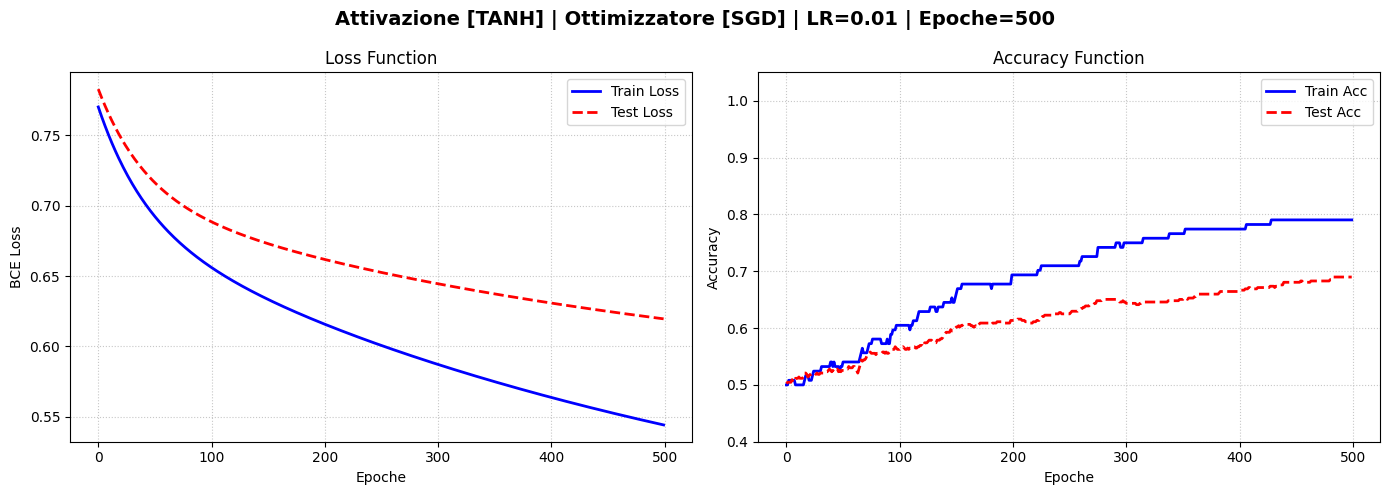

--- Risultati Finali all'Epoca 500 ---
Train Loss: 0.5442 | Train Acc: 79.03%
Test Loss:  0.6196  | Test Acc:  68.98%


In [41]:
hist_tanh_sgd = run_experiment(
    X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor,
    activation='tanh', 
    optimizer_name='sgd', 
    epochs=500, 
    learning_rate=0.01,
    momentum=0.0
)

Unica nota positiva è il fatto che la rete stia imparando (non banale, vedi esperimenti sopra con i modelli lineari).

L'apprendimento è troppo lento: in 500 epochs non siamo arrivati vicini ad una buona approssimazione, ma la curva continua a scendere — probabilmente con molte più epochs convergerebbe.

Il comportamento a gradini nell'accuracy è caratteristico di due fenomeni combinati: (1) la saturazione di tanh, che produce gradienti molto piccoli quando $|z|$ è grande, rallentando drammaticamente gli aggiornamenti; (2) la natura discreta della metrica, dove ogni campione vale circa $\frac{1}{124} \approx 0.8\%$, quindi le predizioni cambiano una alla volta producendo salti visibili.

Senza alcun meccanismo di accumulo, SGD puro applica questi gradienti minuscoli così come sono, senza poterli amplificare.


Secondo esperimento: Tanh + SGD con Momentum.

Il momentum introduce una "memoria" nell'ottimizzatore, accumulando una media mobile esponenziale dei gradienti passati:

$$v_t = \beta v_{t-1} + \nabla L(w_t)$$
$$w_{t+1} = w_t - \eta v_t$$

dove $\beta$ (tipicamente 0.9) controlla quanta storia viene conservata.

Il vantaggio è duplice: (1) i gradienti piccoli ma coerenti nella stessa direzione si accumulano, producendo aggiornamenti significativi anche quando il singolo gradiente è attenuato dalla saturazione di tanh; (2) le oscillazioni lungo direzioni con gradienti alternati si smorzano, stabilizzando la traiettoria.

Seme fissato a: 42. L'esperimento è ora riproducibile.


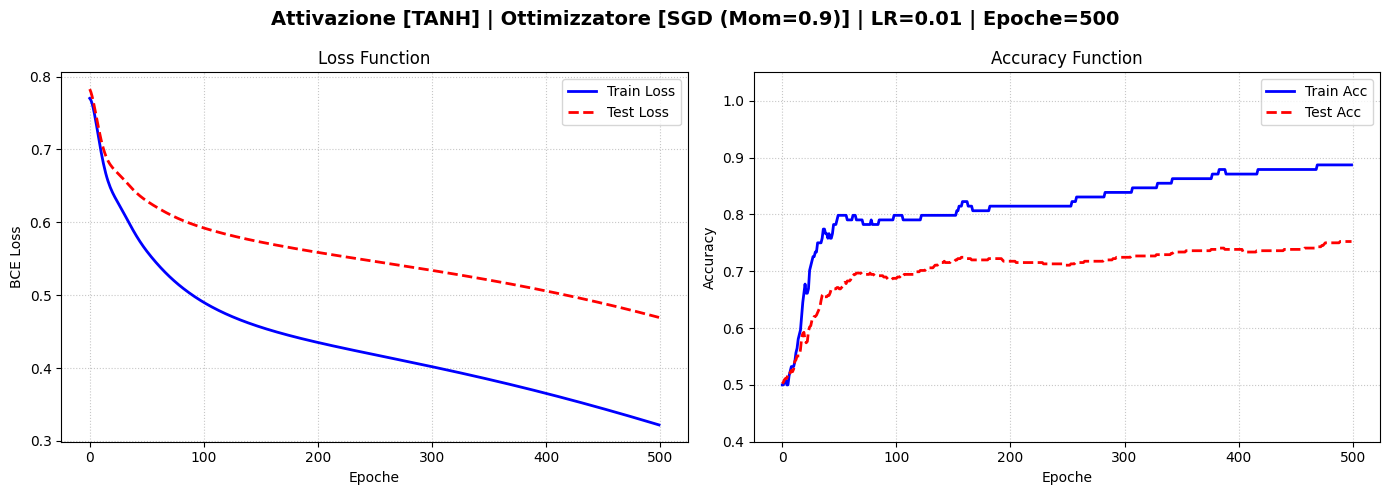

--- Risultati Finali all'Epoca 500 ---
Train Loss: 0.3219 | Train Acc: 88.71%
Test Loss:  0.4694  | Test Acc:  75.23%


In [42]:
hist_tanh_sgd_mom = run_experiment(
    X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor,
    activation='tanh', 
    optimizer_name='sgd', 
    epochs=500, 
    learning_rate=0.01,
    momentum=0.9
)

L'aggiunta del momentum produce un chiaro miglioramento nella velocità di convergenza rispetto all'SGD puro: la train accuracy sale da ~79% a ~89%, e la loss scende significativamente più in fretta.

Tuttavia emerge un fenomeno nuovo: overfitting. Il gap tra train loss (~0.32) e test loss (~0.48) si allarga progressivamente a partire dalle prime decine di epoche, e la test accuracy si ferma intorno al 75% mentre il train continua a salire. Lo SGD puro era troppo lento per manifestare questo problema in 500 epoche — la lentezza mascherava un problema di generalizzazione più profondo.

Il momentum ha quindi risolto la saturazione (i gradienti piccoli vengono accumulati efficacemente), ma la maggiore velocità di apprendimento porta il modello a memorizzare i 124 campioni di training senza generalizzare. Questo suggerisce che per sfruttare il momentum senza overfitting servirà regolarizzazione o un optimizer con capacità di auto-regolazione.

Terzo esperimento Tanh + Adam :

Utilizziamo quindi un Learning Rate adattivo, nel pratico esegue 5 operazioni per ogni parametro :

Calcolo del Gradiente -> $$g_t = \nabla L(w_{t-1})$$

Aggiorna la media mobile esponenziale dei gradienti passati (Momentum) -> $m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$

Aggiorna anche la media mobile esponenziale dei quadrati dei gradienti passati -> $v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$

Poiché $m$ e $v$ partono da zero, nei primissimi passi di addestramento i loro valori tenderanno a essere sbilanciati verso lo zero. Per compensare, Adam li amplifica dividendo per un termine che si riduce col passare del tempo -> $\hat{m}_t = \frac{m_t}{1 - \beta_1^t}$, $\hat{v}_t = \frac{v_t}{1 - \beta_2^t}$

Aggiornamento del Peso -> $w_t = w_{t-1} - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$

$\hat{m}_t$ ci dice da che parte andare

$\sqrt{\hat{v}_t}$ ci da una "validità" della direzione

Seme fissato a: 42. L'esperimento è ora riproducibile.


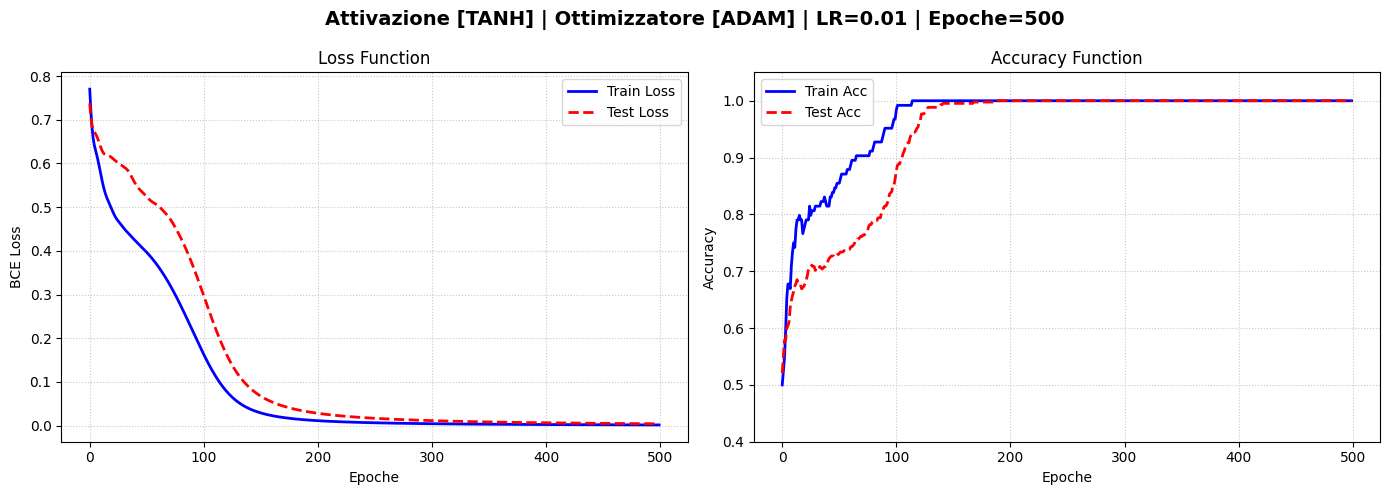

--- Risultati Finali all'Epoca 500 ---
Train Loss: 0.0016 | Train Acc: 100.00%
Test Loss:  0.0043  | Test Acc:  100.00%


In [ ]:
hist_tanh_adam = run_experiment(
    X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor,
    activation='tanh', 
    optimizer_name='adam', 
    epochs=500, 
    learning_rate=0.01
)

Adam ci ha portato all'accuracy di 1, senza overfitting.

è probabile che mentre l'SGD procedeva a zig-zag, Adam ha "raddrizzato" la traiettoria, puntando dritto verso il minimo globale della funzione di costo, grazie al calcolo de Momentum e della media mobile del quadrato dei gradienti, che frenano o accelerano il Lr.

Testiamo ora ReLU + SGD:

ReLU è definita come $f(x) = \max(0, x)$, e la derivata per $x > 0$ è esattamente $x$, per $x \leq 0$ è esattamente $0$. 

Questo introduce il concetto di la sparsità (solo una parte della rete si attiva per un dato input).

f_net di un neurone nel layer $l$ è $z_l = \sum_{i=1}^{n_{in}} w_i x_i$, se assumiamo che $z_l$ sia distribuito in modo simmetrico attorno allo zero, l'applicazione della ReLU dimezza letteralmente la varianza del segnale

$Var(x_{l+1}) = \frac{1}{2} Var(z_l)$

Riprendiamo la formula del calcolo della varianza dell'output (ne abbiamo parlato per Xavier-Glorot)

$$Var(y) = n_{in} \cdot Var(W) \cdot Var(x)$$

Sostituiamo $Var(x_l)$ con la varianza dimezzata che esce dalla ReLU del layer precedente ($l-1$):

$$Var(z_l) = n_{in} \cdot Var(w_l) \cdot \frac{1}{2} Var(z_{l-1})$$

Come per Xavier-Glorot l'obiettivo è mantenere il segnale stabile, la varianza al layer $l$ deve essere identica alla varianza al layer $l-1$. Equazione di conservazione dell'energia:

$$Var(z_l) = Var(z_{l-1})$$

Affinché questa uguaglianza sia vera, il coefficiente moltiplicativo deve essere pari a $1$:

$$n_{in} \cdot Var(w_l) \cdot \frac{1}{2} = 1$$

Risolvendo per la varianza dei pesi $Var(w_l)$, otteniamo l'equazione di He:

$$Var(w_l) = \frac{2}{n_{in}}$$



Seme fissato a: 42. L'esperimento è ora riproducibile.


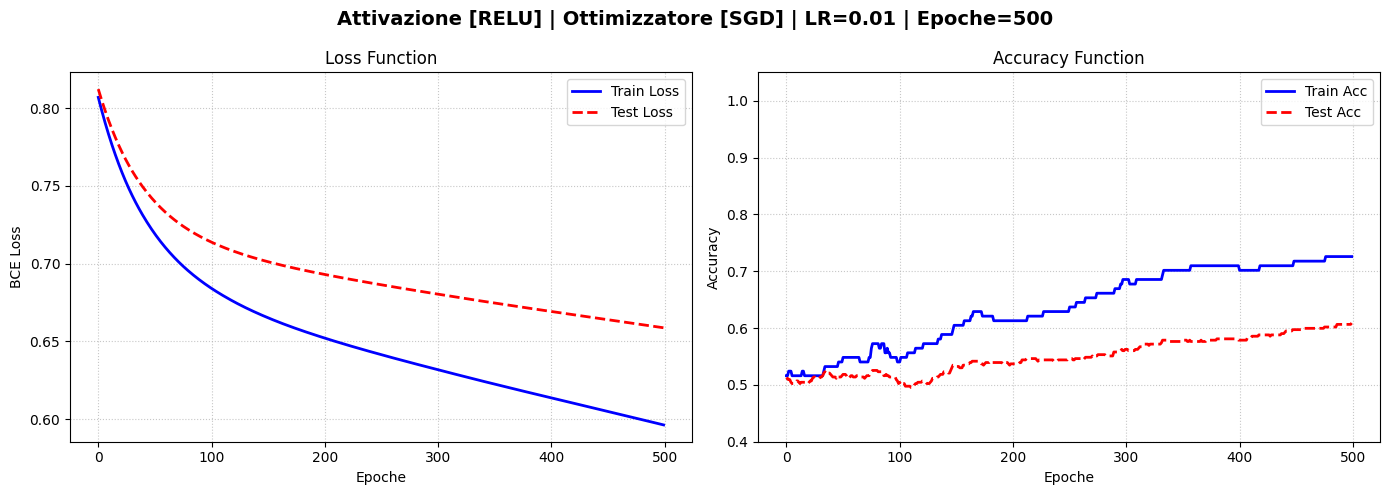

--- Risultati Finali all'Epoca 500 ---
Train Loss: 0.5962 | Train Acc: 72.58%
Test Loss:  0.6587  | Test Acc:  60.88%


In [ ]:

hist_relu_sgd = run_experiment(
    X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor,
    activation='relu', 
    optimizer_name='sgd', 
    epochs=500, 
    learning_rate=0.01
)

Il comportamento conferma la lentezza di SGD.

I risultati numerici ci segnalano che stiamo andando anche più lenti rispetto a Tanh.

Nel grafico della Accuratezza abbiamo un calo intorno a 100 e molte zone piatte, questo è il fenomeno del Dying ReLU:

Per la derivata ri ReLU (definita su) se l'input lineare al neurone $z < 0$, il gradiente è esattamente zero.
Con l'SGD puro, se un aggiornamento dei pesi sfortunato spinge l'input di un neurone in territorio negativo per tutti i campioni del batch, quel neurone "muore". Il suo gradiente sarà 0, i suoi pesi non si aggiorneranno più e l'SGD non ha alcun meccanismo per "rianimarlo".

Proviamo ReLU + SGD con Momentum.

Con tanh il momentum risolveva la saturazione accumulando gradienti piccoli ma non-nulli. Con ReLU la situazione è diversa: il gradiente di un neurone morto è esattamente zero, e nessuna quantità di accumulo produce un aggiornamento da zero ($\beta \cdot v_{t-1} + 0 = \beta \cdot v_{t-1}$: il momentum conserva l'inerzia dai passi precedenti, ma non genera nuovo segnale).

Il momentum può tuttavia aiutare in modo preventivo: aggiornamenti più stabili e meno erratici riducono la probabilità di spingere un neurone in zona negativa per tutti i campioni contemporaneamente, prevenendo la morte piuttosto che curandola.


Seme fissato a: 42. L'esperimento è ora riproducibile.


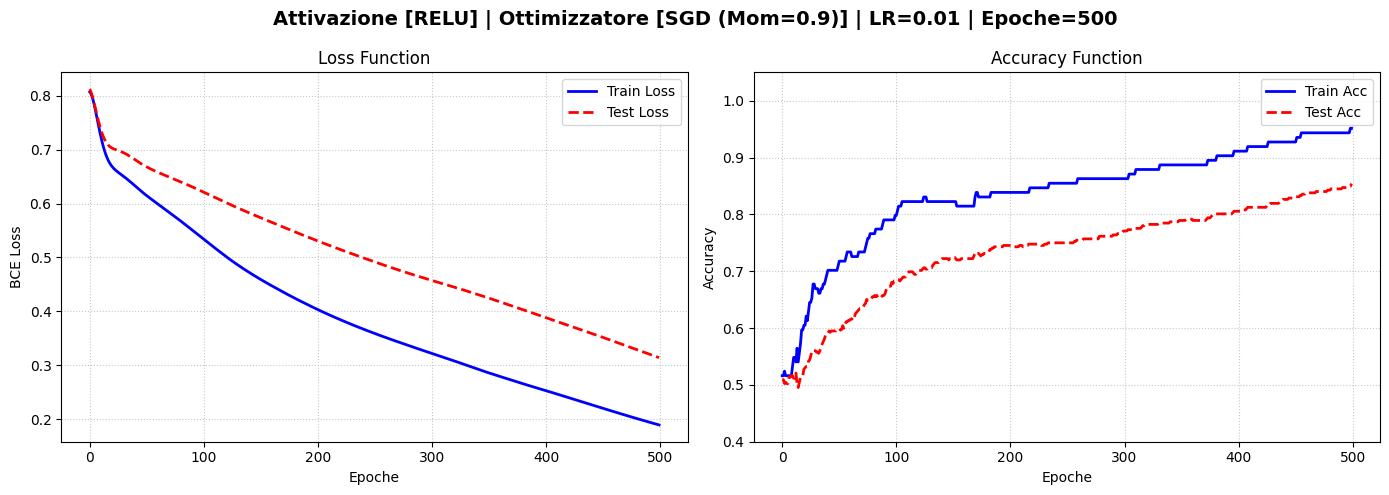

--- Risultati Finali all'Epoca 500 ---
Train Loss: 0.1891 | Train Acc: 95.16%
Test Loss:  0.3139  | Test Acc:  85.42%


In [45]:
hist_relu_sgd_mom = run_experiment(
    X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor,
    activation='relu', 
    optimizer_name='sgd', 
    epochs=500, 
    learning_rate=0.01,
    momentum=0.9
)

Il comportamento è analogo a Tanh+Momentum ma con due differenze. La convergenza è più rapida (train accuracy ~93%, test ~85%) e il dying ReLU è nettamente ridotto: la curva dell'accuracy è più liscia e senza i cali improvvisi dello SGD puro, confermando l'effetto preventivo del momentum che stabilizza gli aggiornamenti e riduce il rischio di spingere neuroni in zona negativa.

Tuttavia ritroviamo lo stesso pattern di overfitting: il gap tra train loss (~0.19) e test loss (~0.32) cresce costantemente. 

Il momentum accelera l'apprendimento su entrambe le attivazioni, ma senza nessun meccanismo di regolazione adattiva produce inevitabilmente overfitting su un training set così piccolo.

Questo rende il passaggio ad Adam particolarmente significativo: Adam raggiungerà il 100% su train e test simultaneamente, suggerendo che il learning rate adattivo non solo accelera la convergenza ma agisce come forma implicita di regolarizzazione — scalando gli aggiornamenti per parametro evita che singoli pesi crescano in modo incontrollato.

Proviamo ReLU + Adam

Seme fissato a: 42. L'esperimento è ora riproducibile.


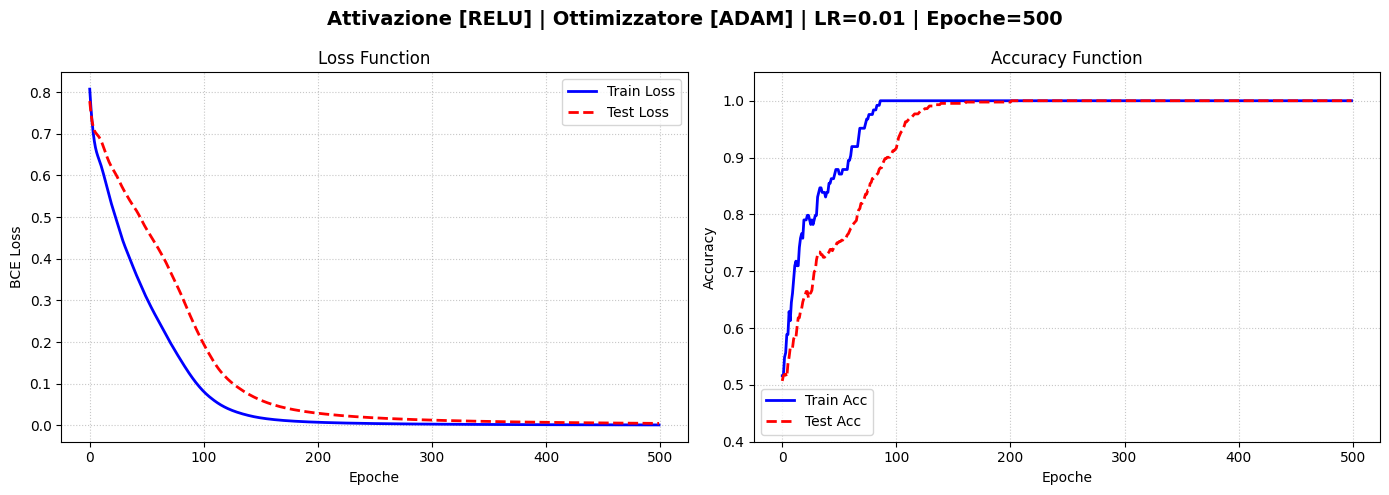

--- Risultati Finali all'Epoca 500 ---
Train Loss: 0.0010 | Train Acc: 100.00%
Test Loss:  0.0047  | Test Acc:  100.00%


In [46]:
hist_relu_adam = run_experiment(
    X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor,
    activation='relu', 
    optimizer_name='adam', 
    epochs=500, 
    learning_rate=0.01
)

Abbiamo ottenuto comunque ottenuto il massimo di Accuracy, con valori di Loss comparabili

La differenza sostanziale sta nella Learning Curve, la quale per ReLU precipita più velocemente nella prima fase del training. La differenza sta nelle derivate delle due funzioni.

La derivata di tanh rispetto all'input è -> $$f'(z) = 1 - \tanh^2(z)$$

Per $\tanh(0) = 0$, quindi la derivata è $1$. In questa zona, il gradiente passa intatto. Mentre più $z$ si allontana da 0 la derivata crolla verso 0.

Abbiamo il fenomeno di Saturazione (Vedi Slides).

La derivata di ReLU è invece -> $$f'(z) = \begin{cases} 1 & \text{se } z > 0 \\ 0 & \text{se } z < 0 \end{cases}$$

Per ogni valore positivo di z la derivata è sempre 1.

La ReLU non satura mai nel semiasse positivo. Non c'è nessun freno. Quando calcoliamo la backpropagation per i neuroni attivi, l'errore passa attraverso la ReLU in modo puro, non attenuato, al $100\%$ della sua forza.
L'ottimizzatore Adam riceve quindi gradienti "interi" e massicci fin dalla primissima epoca, permettendogli di fare salti enormi e decisi verso il minimo della funzione di costo

Proviamo un altro optimizer (citato a Lezione) RMSProp :

Adatta il learning rate per ogni paramentro basandosi sui gradineti passati.

Usa la media mobile esponinziale, in modo da dimenticare gradienti troppo vecchi e concentrarsi solo sui recenti.

$\eta$: Il Tasso di Apprendimento (es. $0.001$).

$\beta$ (spesso indicato con $\rho$ o $\gamma$): Il tasso di decadimento della media mobile (di solito impostato a $0.9$).

$\epsilon$: Una costante piccolissima per evitare la divisione per zero (es. $10^{-8}$).

Si calcola la pendenza dell'errore rispetto al peso : $$g_t = \nabla L(w_{t-1})$$

Aggiorniamo la media dei quadrati dei gradienti: $$v_t = \beta v_{t-1} + (1 - \beta) g_t^2$$ (Uguale al Secondo Momento di Adam).

Infine, aggiorniamo il peso dividendo il gradiente per la radice quadrata di questa media mobile:$$w_t = w_{t-1} - \frac{\eta}{\sqrt{v_t} + \epsilon} g_t$$

Seme fissato a: 42. L'esperimento è ora riproducibile.


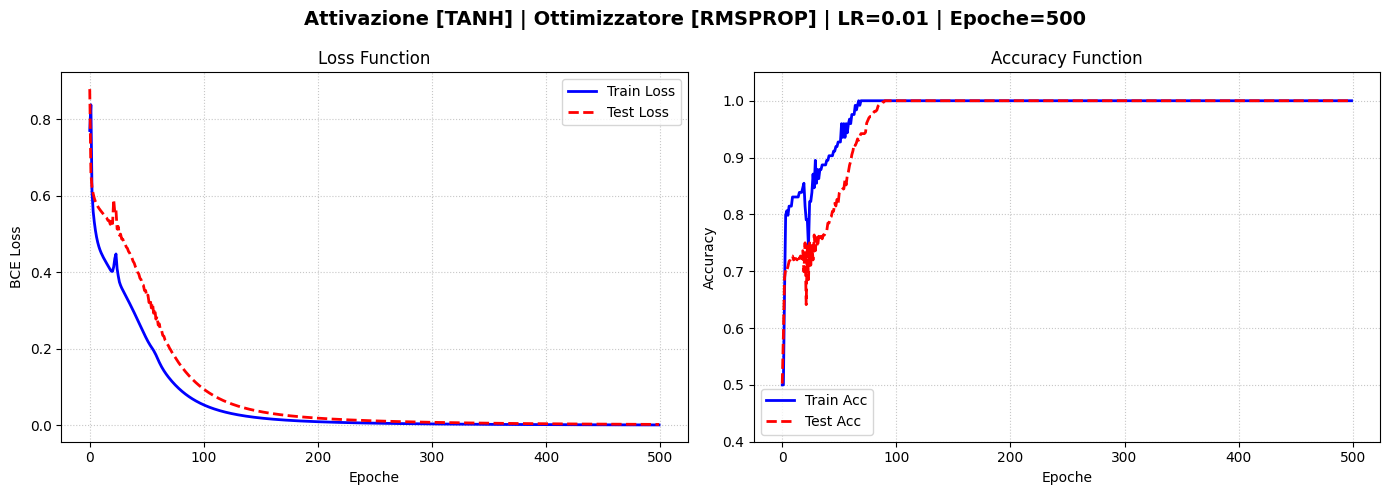

--- Risultati Finali all'Epoca 500 ---
Train Loss: 0.0008 | Train Acc: 100.00%
Test Loss:  0.0022  | Test Acc:  100.00%


In [ ]:
hist_tanh_rmsprop = run_experiment(
    X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor,
    activation='tanh', 
    optimizer_name='rmsprop', 
    epochs=500, 
    learning_rate=0.01
)

Seme fissato a: 42. L'esperimento è ora riproducibile.


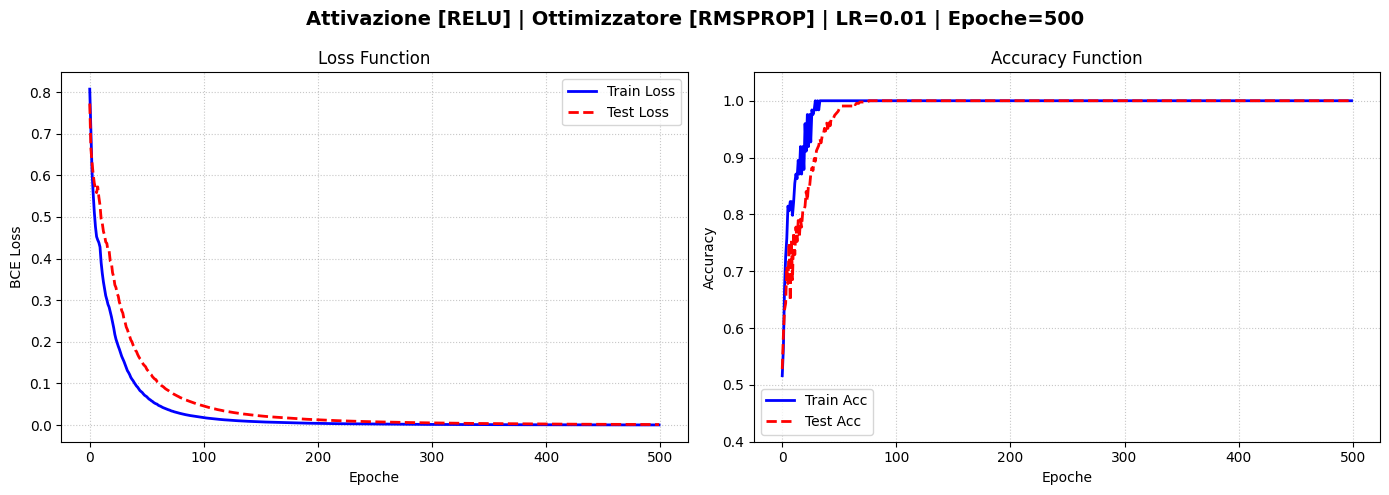

--- Risultati Finali all'Epoca 500 ---
Train Loss: 0.0003 | Train Acc: 100.00%
Test Loss:  0.0013  | Test Acc:  100.00%


In [ ]:
hist_relu_rmsprop = run_experiment(
    X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor,
    activation='relu', 
    optimizer_name='rmsprop', 
    epochs=500, 
    learning_rate=0.01
)

---
**PRIMA VERA GRID-SEARCH** - SU MONK-1

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import KFold

# --- Definizione del Modello Dinamico ---
class DeepDynamicMonk(nn.Module):
    def __init__(self, input_dim, hidden_layers_tuple, act_name):
        super().__init__()
        layers = []
        current_dim = input_dim

        ActClass = nn.ReLU if act_name == 'relu' else nn.Tanh

        for h_dim in hidden_layers_tuple:
            layers.append(nn.Linear(current_dim, h_dim))
            layers.append(ActClass())
            current_dim = h_dim

        layers.append(nn.Linear(current_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def apply_init(model, activation_name):
    """Applica l'inizializzazione corretta in base all'attivazione."""
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if activation_name == 'relu':
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
            else:
                nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)


def run_grid_search(dataset_name, train_path, test_path, param_grid, epochs=500, n_folds=5, plot_best=True):
    """
    Grid Search con K-Fold Cross Validation sul Training Set.
    Il Test Set viene usato SOLO per la valutazione finale del vincitore.
    """
    print(f"=== Avvio Grid Search su {dataset_name.upper()} ===")

    # 1. Data Ingestion
    loader = MonkLoader(dataset_name=dataset_name)
    X_tr_np_full, y_tr_np_full, X_ts_np, y_ts_np = loader.get_data(train_path, test_path)

    # Conversione in tensori
    X_full = torch.tensor(X_tr_np_full, dtype=torch.float32)
    y_full = torch.tensor(y_tr_np_full, dtype=torch.float32).view(-1, 1)

    X_test = torch.tensor(X_ts_np, dtype=torch.float32)
    y_test = torch.tensor(y_ts_np, dtype=torch.float32).view(-1, 1)

    # 2. Spazio di Ricerca
    keys = param_grid.keys()
    values = (param_grid[key] for key in keys)
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

    print(f"Spazio iperparametrico: {len(combinations)} configurazioni x {n_folds} fold = {len(combinations) * n_folds} addestramenti.")
    print(f"Training Set: {len(X_full)} campioni | Test Set: {len(X_test)} campioni (riservato al vincitore)\n")

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    results = []

    # 3. Ciclo di Esplorazione
    for idx, params in enumerate(combinations):
        hidden_layers = params['hidden_layers']
        lr = params['lr']
        activation_name = params['activation']
        optimizer_name = params['optimizer']

        topology_str = "-".join(map(str, hidden_layers)) if hidden_layers else "Linear"

        fold_val_accs = []
        fold_val_losses = []
        fold_train_accs = []
        fold_train_losses = []

        for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_full)):
            # Stesso seed per ogni fold: l'unica variabile è la partizione dei dati
            seed_everything(42, verbose=False)

            X_train_fold = X_full[train_idx]
            y_train_fold = y_full[train_idx]
            X_val_fold = X_full[val_idx]
            y_val_fold = y_full[val_idx]

            model = DeepDynamicMonk(X_full.shape[1], hidden_layers, activation_name)
            apply_init(model, activation_name)

            criterion = nn.BCEWithLogitsLoss()

            if optimizer_name == 'adam':
                optimizer = optim.Adam(model.parameters(), lr=lr)
            elif optimizer_name == 'sgd':
                optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
            elif optimizer_name == 'rmsprop':
                optimizer = optim.RMSprop(model.parameters(), lr=lr)
            else:
                raise ValueError(f"Ottimizzatore non supportato: {optimizer_name}")

            # Training del fold
            for epoch in range(epochs):
                model.train()
                optimizer.zero_grad()
                logits_tr = model(X_train_fold)
                loss_tr = criterion(logits_tr, y_train_fold)
                loss_tr.backward()
                optimizer.step()

            # Valutazione finale del fold
            model.eval()
            with torch.no_grad():
                logits_tr = model(X_train_fold)
                loss_tr = criterion(logits_tr, y_train_fold)
                preds_tr = (torch.sigmoid(logits_tr) >= 0.5).float()
                acc_tr = (preds_tr == y_train_fold).float().mean().item()

                logits_val = model(X_val_fold)
                loss_val = criterion(logits_val, y_val_fold)
                preds_val = (torch.sigmoid(logits_val) >= 0.5).float()
                acc_val = (preds_val == y_val_fold).float().mean().item()

            fold_train_accs.append(acc_tr)
            fold_train_losses.append(loss_tr.item())
            fold_val_accs.append(acc_val)
            fold_val_losses.append(loss_val.item())

        results.append({
            'Activation': activation_name.upper(),
            'Optimizer': optimizer_name.upper(),
            'Topology': topology_str,
            'Learning_Rate': lr,
            'Mean_Train_Acc': round(np.mean(fold_train_accs) * 100, 2),
            'Mean_Val_Acc': round(np.mean(fold_val_accs) * 100, 2),
            'Std_Val_Acc': round(np.std(fold_val_accs) * 100, 2),
            'Mean_Val_Loss': round(np.mean(fold_val_losses), 4),
        })

        if (idx + 1) % 10 == 0 or (idx + 1) == len(combinations):
            print(f"Progresso: {idx + 1}/{len(combinations)} configurazioni completate.")

    # 4. Classifica basata SOLO su Validation
    df_results = pd.DataFrame(results)
    cols = ['Activation', 'Optimizer', 'Topology', 'Learning_Rate',
            'Mean_Train_Acc', 'Mean_Val_Acc', 'Std_Val_Acc', 'Mean_Val_Loss']
    df_results = df_results[cols].sort_values(
        by=['Mean_Val_Acc', 'Mean_Val_Loss'], ascending=[False, True]
    ).reset_index(drop=True)

    print("\n=== CLASSIFICA (TOP 10) — Basata su Validation ===")
    display(df_results.head(10))

    # 5. Analisi del Vincitore
    if plot_best and not df_results.empty:
        best_row = df_results.iloc[0]
        best_act = best_row['Activation'].lower()
        best_opt = best_row['Optimizer'].lower()
        best_topo_str = best_row['Topology']
        best_lr = best_row['Learning_Rate']

        best_hl_tuple = next(
            hl for hl in param_grid['hidden_layers']
            if ("-".join(map(str, hl)) if hl else "Linear") == best_topo_str
        )

        # --- FASE A: Training sul primo fold per generare le Learning Curves ---
        first_fold = list(kf.split(X_full))[0]
        X_train_plot = X_full[first_fold[0]]
        y_train_plot = y_full[first_fold[0]]
        X_val_plot = X_full[first_fold[1]]
        y_val_plot = y_full[first_fold[1]]

        seed_everything(42, verbose=False)
        plot_model = DeepDynamicMonk(X_full.shape[1], best_hl_tuple, best_act)
        apply_init(plot_model, best_act)

        criterion = nn.BCEWithLogitsLoss()
        if best_opt == 'adam':
            opt_plot = optim.Adam(plot_model.parameters(), lr=best_lr)
        elif best_opt == 'sgd':
            opt_plot = optim.SGD(plot_model.parameters(), lr=best_lr, momentum=0.9)
        elif best_opt == 'rmsprop':
            opt_plot = optim.RMSprop(plot_model.parameters(), lr=best_lr)

        curve_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

        for epoch in range(epochs):
            plot_model.train()
            opt_plot.zero_grad()
            logits_tr = plot_model(X_train_plot)
            loss_tr = criterion(logits_tr, y_train_plot)
            loss_tr.backward()
            opt_plot.step()

            plot_model.eval()
            with torch.no_grad():
                preds_tr = (torch.sigmoid(logits_tr) >= 0.5).float()
                acc_tr = (preds_tr == y_train_plot).float().mean().item()

                logits_val = plot_model(X_val_plot)
                loss_val = criterion(logits_val, y_val_plot)
                preds_val = (torch.sigmoid(logits_val) >= 0.5).float()
                acc_val = (preds_val == y_val_plot).float().mean().item()

            curve_history['train_loss'].append(loss_tr.item())
            curve_history['val_loss'].append(loss_val.item())
            curve_history['train_acc'].append(acc_tr)
            curve_history['val_acc'].append(acc_val)

        # Grafico: Train vs Validation
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(
            f"VINCITORE | {best_act.upper()} + {best_opt.upper()} | Topo=[{best_topo_str}] | LR={best_lr}",
            fontsize=14, fontweight='bold'
        )

        ax1.plot(curve_history['train_loss'], color='blue', linewidth=2, label='Train Loss')
        ax1.plot(curve_history['val_loss'], color='orange', linestyle='--', linewidth=2, label='Validation Loss')
        ax1.set_title('Loss')
        ax1.set_xlabel('Epoche')
        ax1.set_ylabel('BCE Loss')
        ax1.grid(True, linestyle=':', alpha=0.7)
        ax1.legend()

        ax2.plot(curve_history['train_acc'], color='blue', linewidth=2, label='Train Acc')
        ax2.plot(curve_history['val_acc'], color='orange', linestyle='--', linewidth=2, label='Validation Acc')
        ax2.set_title('Accuracy')
        ax2.set_xlabel('Epoche')
        ax2.set_ylabel('Accuracy')
        ax2.set_ylim([0.4, 1.05])
        ax2.grid(True, linestyle=':', alpha=0.7)
        ax2.legend()

        plt.tight_layout()
        plt.show()

        # --- FASE B: Retraining sull'intero Training Set + Valutazione su Test ---
        seed_everything(42, verbose=False)
        final_model = DeepDynamicMonk(X_full.shape[1], best_hl_tuple, best_act)
        apply_init(final_model, best_act)

        criterion = nn.BCEWithLogitsLoss()
        if best_opt == 'adam':
            optimizer = optim.Adam(final_model.parameters(), lr=best_lr)
        elif best_opt == 'sgd':
            optimizer = optim.SGD(final_model.parameters(), lr=best_lr, momentum=0.9)
        elif best_opt == 'rmsprop':
            optimizer = optim.RMSprop(final_model.parameters(), lr=best_lr)

        for epoch in range(epochs):
            final_model.train()
            optimizer.zero_grad()
            logits_tr = final_model(X_full)
            loss_tr = criterion(logits_tr, y_full)
            loss_tr.backward()
            optimizer.step()

        # Valutazione finale (una sola volta)
        final_model.eval()
        with torch.no_grad():
            logits_tr = final_model(X_full)
            preds_tr = (torch.sigmoid(logits_tr) >= 0.5).float()
            final_train_acc = (preds_tr == y_full).float().mean().item()

            logits_ts = final_model(X_test)
            loss_ts = criterion(logits_ts, y_test)
            preds_ts = (torch.sigmoid(logits_ts) >= 0.5).float()
            final_test_acc = (preds_ts == y_test).float().mean().item()

        print(f"\n--- Valutazione Finale del Vincitore (Retrained su intero Training Set) ---")
        print(f"Config: {best_act.upper()} + {best_opt.upper()} | Topologia=[{best_topo_str}] | LR={best_lr}")
        print(f"Train Acc: {final_train_acc*100:.2f}%")
        print(f"Test Acc:  {final_test_acc*100:.2f}%  | Test Loss: {loss_ts.item():.4f}")

    return df_results

**GRID**:

Partiamo semplici :

Architettura -> sappiamo che SVM Poly con degree = 2 lo risolve -> dovrebbero 1 layer, poche units (2,) / (4,)

Learning Rate -> andiamo di ordini di 10 -> 0.01, 0.001, 0.0001

Per Funzioni di attivazione e optimizer manteniamo quelli della prima prova

=== Avvio Grid Search su MONKS-1 ===
--- Dataset Loaded: monks-1 ---
X_train shape: (124, 17) | Type: float32
y_train shape: (124,)        | Type: int64
X_test shape:  (432, 17)
Features originali: 6 -> OneHot Features: 17
----------------------------------------
Spazio iperparametrico: 24 configurazioni x 5 fold = 120 addestramenti.
Training Set: 124 campioni | Test Set: 432 campioni (riservato al vincitore)

Progresso: 10/24 configurazioni completate.
Progresso: 20/24 configurazioni completate.
Progresso: 24/24 configurazioni completate.

=== CLASSIFICA (TOP 10) — Basata su Validation ===


,Activation,Optimizer,Topology,Learning_Rate,Mean_Train_Acc,Mean_Val_Acc,Std_Val_Acc,Mean_Val_Loss
0,RELU,ADAM,2,0.010,100.00,100.00,0.00,0.0386
1,TANH,ADAM,4,0.010,100.00,95.83,8.33,0.1224
2,RELU,ADAM,4,0.010,93.55,93.53,4.11,0.2124
3,RELU,SGD,2,0.010,95.76,87.97,5.61,0.3049
4,RELU,SGD,4,0.010,86.69,83.87,5.07,0.4017
5,TANH,SGD,4,0.010,91.54,78.93,7.32,0.4386
6,TANH,ADAM,4,0.001,84.06,75.77,7.30,0.5328
7,TANH,ADAM,2,0.001,82.05,74.17,7.07,0.5392
8,TANH,ADAM,2,0.010,93.95,73.43,8.50,0.5537
9,RELU,ADAM,2,0.001,80.24,73.37,8.29,0.5815


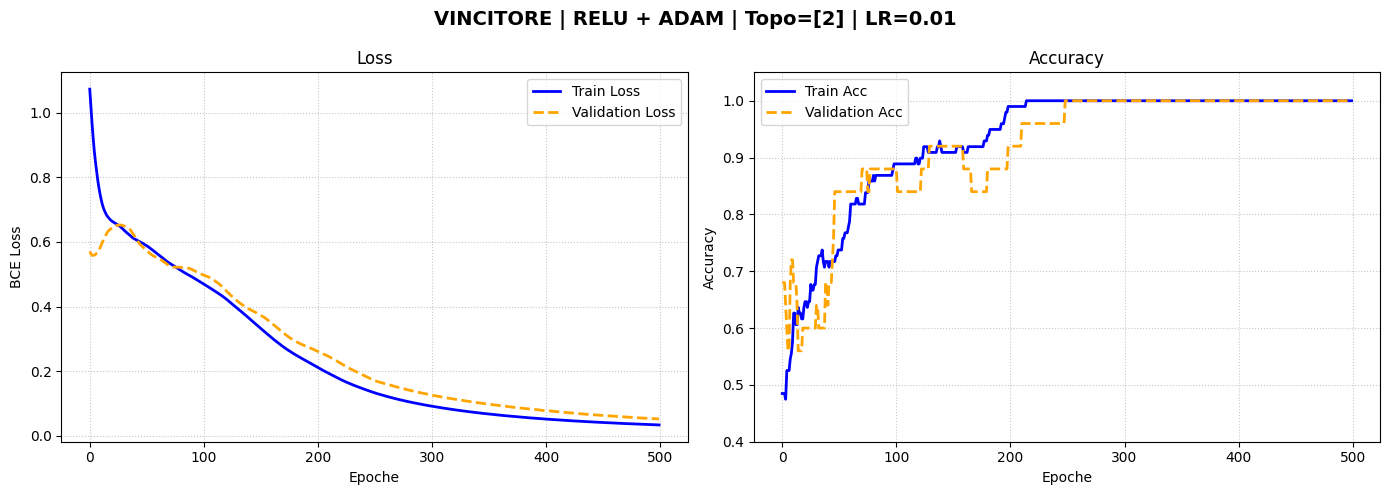


--- Valutazione Finale del Vincitore (Retrained su intero Training Set) ---
Config: RELU + ADAM | Topologia=[2] | LR=0.01
Train Acc: 100.00%
Test Acc:  100.00%  | Test Loss: 0.0336


In [57]:
# --- CONFIGURAZIONE GRID SEARCH MONK-1 ---
DATASET = 'monks-1'
TRAIN_FILE = f'./datasets/{DATASET}.train'
TEST_FILE = f'./datasets/{DATASET}.test'
 
grid_parameters = {
    'activation': ['tanh', 'relu'],
    'optimizer': ['adam', 'sgd'],
    'hidden_layers': [
        (2,),
        (4,)
    ],
    'lr': [0.01, 0.001, 0.0001]
}
 
# 2 * 2 * 3 * 3 = 36 configurazioni x 5 fold = 180 addestramenti
df_risultati_m1 = run_grid_search(
    dataset_name=DATASET,
    train_path=TRAIN_FILE,
    test_path=TEST_FILE,
    param_grid=grid_parameters,
    epochs=500,
    n_folds=5,
    plot_best=True
)

Confermiamo il massimo dell'Accuracy. Ce lo aspettavamo avendolo già ritrovato nella SVM + Teorema di Approssimazione Universale.

Bastano sono 2 unità

---
**MONK-2** :

Saltiamo direttamente alla GridSearch.

Gli altri modelli, differentemente dal caso Monk-1, non sono riusciti a risolvere il problema.

Supponendo quindi che sia più difficile di Monk-1 (Vedi note SVM Monk-2) testiamo anche un numero di Layers superiore ad 1 -> (2, 2)

=== Avvio Grid Search su MONKS-2 ===
--- Dataset Loaded: monks-2 ---
X_train shape: (169, 17) | Type: float32
y_train shape: (169,)        | Type: int64
X_test shape:  (432, 17)
Features originali: 6 -> OneHot Features: 17
----------------------------------------
Spazio iperparametrico: 36 configurazioni x 5 fold = 180 addestramenti.
Training Set: 169 campioni | Test Set: 432 campioni (riservato al vincitore)

Progresso: 10/36 configurazioni completate.
Progresso: 20/36 configurazioni completate.
Progresso: 30/36 configurazioni completate.
Progresso: 36/36 configurazioni completate.

=== CLASSIFICA (TOP 10) — Basata su Validation ===


,Activation,Optimizer,Topology,Learning_Rate,Mean_Train_Acc,Mean_Val_Acc,Std_Val_Acc,Mean_Val_Loss
0,RELU,ADAM,2,0.010,100.00,100.00,0.00,0.0220
1,TANH,ADAM,4,0.010,99.70,97.04,1.86,0.1234
2,TANH,ADAM,2-2,0.010,89.50,86.97,11.57,0.2547
3,RELU,ADAM,2-2,0.010,83.44,82.17,13.19,0.3246
4,RELU,SGD,2-2,0.010,85.94,79.95,9.31,0.3472
5,TANH,ADAM,2,0.010,86.25,79.84,5.59,0.3926
6,RELU,SGD,2,0.010,84.30,79.41,20.03,0.3987
7,RELU,ADAM,2-2,0.001,75.89,69.16,8.76,0.4556
8,RELU,ADAM,4,0.010,80.47,68.04,6.31,0.8316
9,TANH,SGD,4,0.010,73.38,66.83,9.70,0.6189


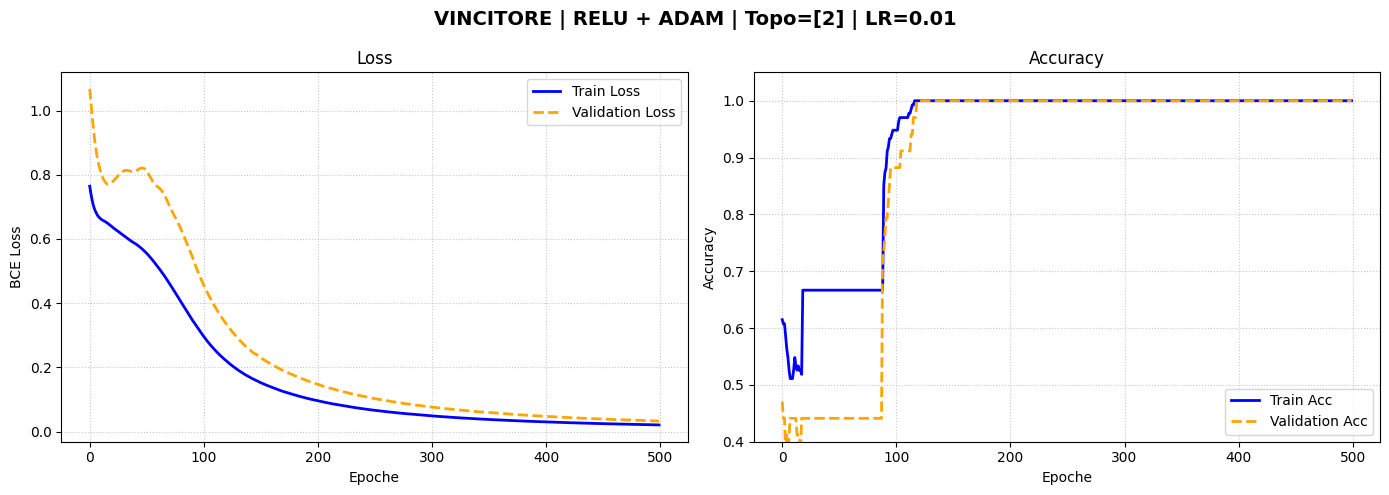


--- Valutazione Finale del Vincitore (Retrained su intero Training Set) ---
Config: RELU + ADAM | Topologia=[2] | LR=0.01
Train Acc: 100.00%
Test Acc:  100.00%  | Test Loss: 0.0196


In [58]:
# --- CONFIGURAZIONE GRID SEARCH MONK-2 ---
DATASET = 'monks-2'
TRAIN_FILE = f'./datasets/{DATASET}.train'
TEST_FILE = f'./datasets/{DATASET}.test'
 
grid_parameters = {
    'activation': ['tanh', 'relu'],
    'optimizer': ['adam', 'sgd'],
    'hidden_layers': [
        (2,),
        (4,),           
        (2, 2)      # Aggiungiamo un secondo layer
    ],
    'lr': [0.01, 0.001, 0.0001]
}

df_risultati_m2 = run_grid_search(
    dataset_name=DATASET,
    train_path=TRAIN_FILE,
    test_path=TEST_FILE,
    param_grid=grid_parameters,
    epochs=500,
    n_folds=5,
    plot_best=True
)

Anche in questo caso basta 1 layer con 2 neuroni, mostrandoci l'elevata capacità di una rete neurale anche piccola 

---
**MONK-3**: 

Questo test sulla NN ci darà la conferma o meno della presenza di rumore.

Oltre al secondo layer aggiungeremo anche un terzo

=== Avvio Grid Search su MONKS-3 ===
--- Dataset Loaded: monks-3 ---
X_train shape: (122, 17) | Type: float32
y_train shape: (122,)        | Type: int64
X_test shape:  (432, 17)
Features originali: 6 -> OneHot Features: 17
----------------------------------------
Spazio iperparametrico: 48 configurazioni x 5 fold = 240 addestramenti.
Training Set: 122 campioni | Test Set: 432 campioni (riservato al vincitore)

Progresso: 10/48 configurazioni completate.
Progresso: 20/48 configurazioni completate.
Progresso: 30/48 configurazioni completate.
Progresso: 40/48 configurazioni completate.
Progresso: 48/48 configurazioni completate.

=== CLASSIFICA (TOP 10) — Basata su Validation ===


,Activation,Optimizer,Topology,Learning_Rate,Mean_Train_Acc,Mean_Val_Acc,Std_Val_Acc,Mean_Val_Loss
0,TANH,ADAM,4-2,0.001,94.26,93.40,4.23,0.3319
1,RELU,SGD,2,0.010,94.47,92.60,3.14,0.3513
2,TANH,SGD,4-2,0.010,97.33,92.53,7.18,0.2528
3,TANH,SGD,4,0.010,94.26,91.80,2.64,0.3002
4,RELU,SGD,4,0.010,93.65,91.80,2.64,0.3161
5,TANH,SGD,2,0.001,93.65,91.80,2.64,0.3944
6,TANH,SGD,2,0.010,94.26,91.77,4.60,0.2917
7,TANH,ADAM,2,0.010,96.52,91.73,6.97,0.2916
8,TANH,SGD,8-4-2,0.001,93.65,91.00,3.03,0.3869
9,TANH,ADAM,8-4-2,0.001,98.77,90.97,4.11,0.2896


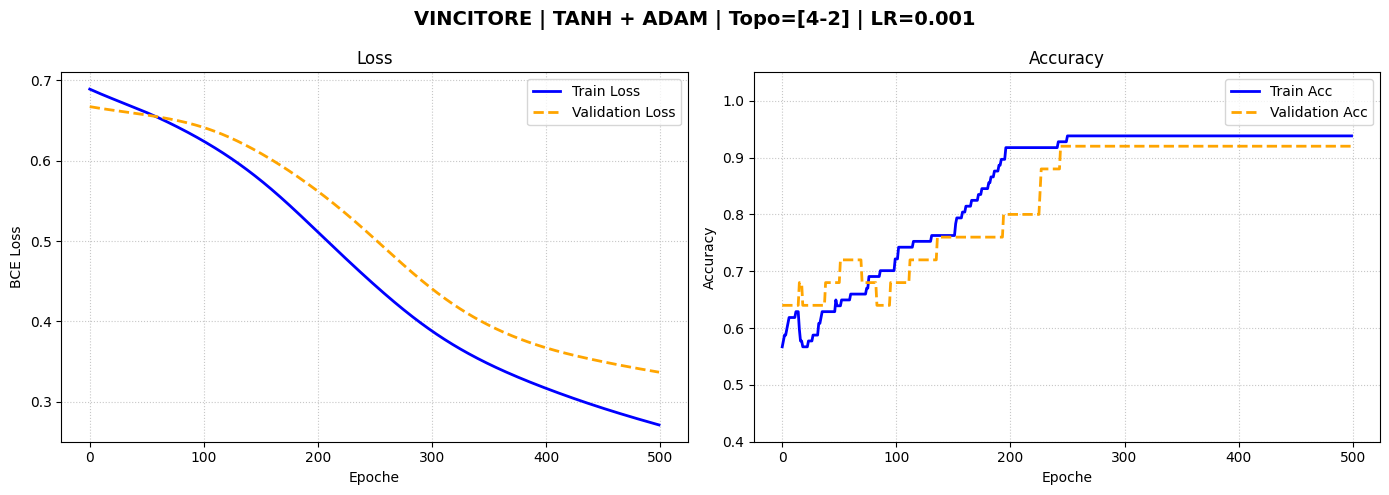


--- Valutazione Finale del Vincitore (Retrained su intero Training Set) ---
Config: TANH + ADAM | Topologia=[4-2] | LR=0.001
Train Acc: 93.44%
Test Acc:  97.22%  | Test Loss: 0.2432


In [59]:
# --- CONFIGURAZIONE GRID SEARCH MONK-3 ---
DATASET = 'monks-3'
TRAIN_FILE = f'./datasets/{DATASET}.train'
TEST_FILE = f'./datasets/{DATASET}.test'
 
grid_parameters = {
    'activation': ['tanh', 'relu'],
    'optimizer': ['adam', 'sgd'],
    'hidden_layers': [
        (2,),
        (4,),
        (4, 2),
        (8, 4, 2)       # Cerchiamo di dimostrare che il problema non sia il modello -> arriviamo fino a 3 layers
    ],
    'lr': [0.01, 0.001, 0.0001]
}

df_risultati_m3 = run_grid_search(
    dataset_name=DATASET,
    train_path=TRAIN_FILE,
    test_path=TEST_FILE,
    param_grid=grid_parameters,
    epochs=500,
    n_folds=5,
    plot_best=True
)

Nemmeno in questo caso riusciamo a risolvere MONK-3, in più manteniamo lo stesso identico risultato visto sul Test-Set degli altri modelli -> 97.22

Direi che abbiamo una prova ulteriore della presenza del rumore